In [1]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 51.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

```
MobileNetV4
EfficientNetV2-S
ConvNeXt-Tiny
DINOv3 ViT-Small
SigLIP-2 ViT
MobileCLIP-2 FastViT
CSATv2
```

In [2]:
import os
import shutil
import random
from pathlib import Path
import timm
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch.optim as optim
from tqdm import tqdm
import os
from collections import defaultdict
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_score, recall_score, balanced_accuracy_score,
    top_k_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

print("🔥 Imports Loaded!!!")

🔥 Imports Loaded!!!


In [3]:
# Get all DINOv3 models
models = timm.list_models("*dinov3*")

results = []

for model_name in models:
    model = timm.create_model(model_name, pretrained=False)

    # Total parameters
    params = sum(p.numel() for p in model.parameters())

    # Trainable parameters
    trainable_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    results.append({
        "Model": model_name,
        "Params_M": params / 1e6,
        "Trainable_M": trainable_params / 1e6
    })

# Create dataframe
df = pd.DataFrame(results)

# Sort by parameter count (smallest → largest)
df = df.sort_values("Params_M").reset_index(drop=True)

# Pretty print
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print(df)

# Optional: top 5 smallest models
print("\nTop 5 Smallest DINOv3 Models:")
print(df.head(5))

                                 Model     Params_M  Trainable_M
0             vit_small_patch16_dinov3    21.586944    21.586944
1        vit_small_patch16_dinov3_qkvb    21.596160    21.596160
2        vit_small_plus_patch16_dinov3    28.683264    28.683264
3   vit_small_plus_patch16_dinov3_qkvb    28.692480    28.692480
4              vit_base_patch16_dinov3    85.641216    85.641216
5         vit_base_patch16_dinov3_qkvb    85.659648    85.659648
6             vit_large_patch16_dinov3   303.079424   303.079424
7        vit_large_patch16_dinov3_qkvb   303.128576   303.128576
8         vit_huge_plus_patch16_dinov3   840.509440   840.509440
9    vit_huge_plus_patch16_dinov3_qkvb   840.591360   840.591360
10               vit_7b_patch16_dinov3  6716.030976  6716.030976

Top 5 Smallest DINOv3 Models:
                                Model   Params_M  Trainable_M
0            vit_small_patch16_dinov3  21.586944    21.586944
1       vit_small_patch16_dinov3_qkvb  21.596160    21.596160
2  

In [4]:
models = timm.list_models()

print(f"Total models: {len(models)}")

mobilenetv4_models = timm.list_models("*mobilenetv4*")

print(f"Found {len(mobilenetv4_models)} MobileNetV4 models:\n")

for model in mobilenetv4_models:
    print(model)

Total models: 1284
Found 12 MobileNetV4 models:

mobilenetv4_conv_aa_large
mobilenetv4_conv_aa_medium
mobilenetv4_conv_blur_medium
mobilenetv4_conv_large
mobilenetv4_conv_medium
mobilenetv4_conv_small
mobilenetv4_conv_small_035
mobilenetv4_conv_small_050
mobilenetv4_hybrid_large
mobilenetv4_hybrid_large_075
mobilenetv4_hybrid_medium
mobilenetv4_hybrid_medium_075


In [5]:
# ==========================
# Configuration
# ==========================
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42


SOURCE_DIR = "/kaggle/input/datasets/dillihangrai078/kirat-rai-lipi-consonant-characters/Consonant"
OUTPUT_DIR = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"


random.seed(RANDOM_SEED)

# ==========================
# Create output directories
# ==========================
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

# ==========================
# Process each class folder
# ==========================
class_folders = [
    f for f in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, f))
]

for class_name in class_folders:

    class_path = os.path.join(SOURCE_DIR, class_name)

    files = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
    ]

    random.shuffle(files)

    n = len(files)

    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    split_map = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split_name, split_files in split_map.items():

        target_class_dir = os.path.join(
            OUTPUT_DIR,
            split_name,
            class_name
        )

        os.makedirs(target_class_dir, exist_ok=True)

        for file_name in split_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(target_class_dir, file_name)

            shutil.copy2(src, dst)

    print(
        f"{class_name}: "
        f"Train={len(train_files)}, "
        f"Val={len(val_files)}, "
        f"Test={len(test_files)}"
    )

print("\nDataset split completed.")

 DHA: Train=23, Val=4, Test=6
NA: Train=23, Val=4, Test=6
WA: Train=24, Val=5, Test=6
RA: Train=20, Val=4, Test=5
TA: Train=10, Val=2, Test=3
DA: Train=23, Val=4, Test=6
KHA: Train=21, Val=4, Test=6
JA: Train=9, Val=2, Test=3
PHA: Train=13, Val=2, Test=4
TTHA: Train=22, Val=4, Test=6
YA: Train=22, Val=4, Test=6
BHA: Train=24, Val=5, Test=6
BA: Train=21, Val=4, Test=6
NYA: Train=28, Val=6, Test=7
MA: Train=21, Val=4, Test=6
THA: Train=9, Val=2, Test=3
JHA: Train=23, Val=4, Test=6
PA: Train=24, Val=5, Test=6
SHA: Train=21, Val=4, Test=6
CA: Train=21, Val=4, Test=5
GA: Train=20, Val=4, Test=5
TTA: Train=21, Val=4, Test=5
GHA: Train=21, Val=4, Test=6
NGA: Train=19, Val=4, Test=5
CHA: Train=10, Val=2, Test=3
DDA: Train=23, Val=4, Test=6
KA: Train=17, Val=3, Test=5
Ddha: Train=21, Val=4, Test=6
LA: Train=19, Val=4, Test=5
HA: Train=23, Val=4, Test=6
SA: Train=22, Val=4, Test=6

Dataset split completed.


In [6]:
def count_dataset_split(path):
    class_counts = {}
    total = 0

    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if not os.path.isdir(cls_path):
            continue

        count = len([
            f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
        ])

        class_counts[cls] = count
        total += count

    return class_counts, total
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"
train_path = f"{DATA_ROOT}/train"
val_path   = f"{DATA_ROOT}/val"
test_path  = f"{DATA_ROOT}/test"

train_counts, train_total = count_dataset_split(train_path)
val_counts, val_total     = count_dataset_split(val_path)
test_counts, test_total   = count_dataset_split(test_path)

print("\n===== TRAIN =====")
print("Total:", train_total)
for k, v in train_counts.items():
    print(k, ":", v)

print("\n===== VAL =====")
print("Total:", val_total)
for k, v in val_counts.items():
    print(k, ":", v)

print("\n===== TEST =====")
print("Total:", test_total)
for k, v in test_counts.items():
    print(k, ":", v)

grand_total = train_total + val_total + test_total

print("\n===== OVERALL =====")
print("Train:", train_total)
print("Val:", val_total)
print("Test:", test_total)
print("TOTAL DATASET SIZE:", grand_total)


===== TRAIN =====
Total: 618
 DHA : 23
BA : 21
BHA : 24
CA : 21
CHA : 10
DA : 23
DDA : 23
Ddha : 21
GA : 20
GHA : 21
HA : 23
JA : 9
JHA : 23
KA : 17
KHA : 21
LA : 19
MA : 21
NA : 23
NGA : 19
NYA : 28
PA : 24
PHA : 13
RA : 20
SA : 22
SHA : 21
TA : 10
THA : 9
TTA : 21
TTHA : 22
WA : 24
YA : 22

===== VAL =====
Total: 118
 DHA : 4
BA : 4
BHA : 5
CA : 4
CHA : 2
DA : 4
DDA : 4
Ddha : 4
GA : 4
GHA : 4
HA : 4
JA : 2
JHA : 4
KA : 3
KHA : 4
LA : 4
MA : 4
NA : 4
NGA : 4
NYA : 6
PA : 5
PHA : 2
RA : 4
SA : 4
SHA : 4
TA : 2
THA : 2
TTA : 4
TTHA : 4
WA : 5
YA : 4

===== TEST =====
Total: 166
 DHA : 6
BA : 6
BHA : 6
CA : 5
CHA : 3
DA : 6
DDA : 6
Ddha : 6
GA : 5
GHA : 6
HA : 6
JA : 3
JHA : 6
KA : 5
KHA : 6
LA : 5
MA : 6
NA : 6
NGA : 5
NYA : 7
PA : 6
PHA : 4
RA : 5
SA : 6
SHA : 6
TA : 3
THA : 3
TTA : 5
TTHA : 6
WA : 6
YA : 6

===== OVERALL =====
Train: 618
Val: 118
Test: 166
TOTAL DATASET SIZE: 902


Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  vit_small_patch16_dinov3


model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Model: vit_small_patch16_dinov3
Trainable parameters: 14,190,751
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 14.07it/s]


Train Loss: 3.4645 | Acc: 2.14%
Val   Loss: 3.4497 | Acc: 4.24%
✅ Best model saved! Val Acc: 4.24%

Epoch 2/200


...

Train Loss: 2.5845 | Acc: 24.51%
Val   Loss: 2.6186 | Acc: 27.12%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 13.51it/s]


Train Loss: 2.6027 | Acc: 26.64%
Val   Loss: 2.6189 | Acc: 27.12%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 13.65it/s]


Train Loss: 2.5566 | Acc: 27.30%
Val   Loss: 2.6189 | Acc: 27.12%

Training finished! Best Validation Accuracy: 29.66%


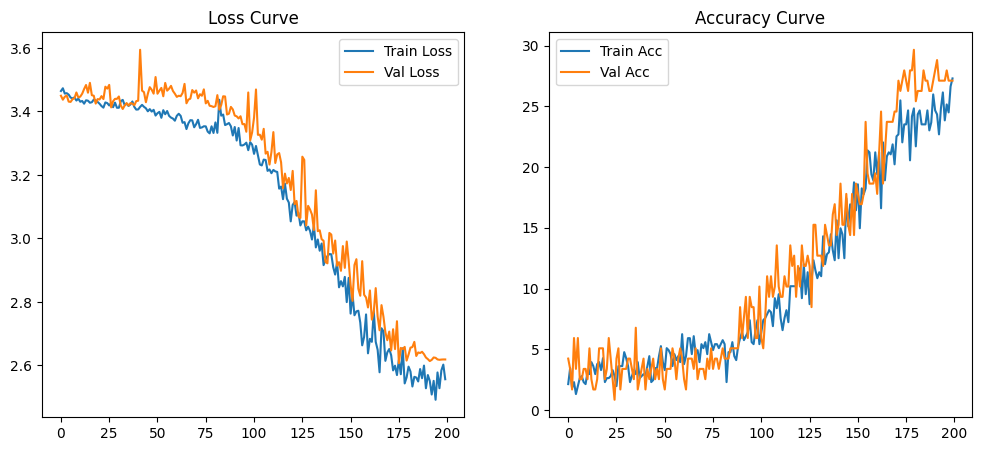

Test: 100%|██████████| 11/11 [00:00<00:00, 14.06it/s]



Final Test Accuracy: 22.89%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 14.03it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le


CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     0.0000    0.0000    0.0000         6
          BA     0.3333    0.3333    0.3333         6
         BHA     0.5000    0.6667    0.5714         6
          CA     0.0000    0.0000    0.0000         5
         CHA     0.2000    0.3333    0.2500         3
          DA     0.0000    0.0000    0.0000         6
         DDA     0.3333    0.3333    0.3333         6
        Ddha     0.1667    0.1667    0.1667         6
          GA     0.3333    0.8000    0.4706         5
         GHA     0.0000    0.0000    0.0000         6
          HA     0.0000    0.0000    0.0000         6
          JA     0.1000    0.3333    0.1538         3
         JHA     0.0000    0.0000    0.0000         6
          KA     0.3333    0.2000    0.2500         5
         KHA     0.1429    0.1667    0.1538         6
          LA     0.0000    0.0000    0.0000         5
          MA     0.6667    0.3333    0.4444         6
   

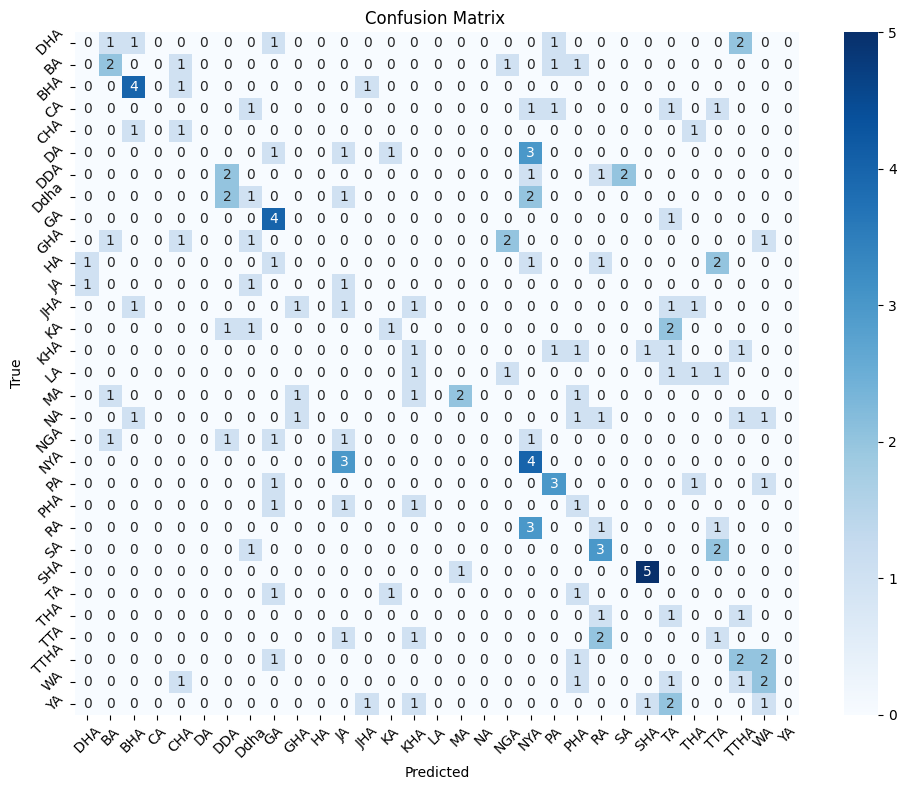

Using device: cuda
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_vit_small_patch16_dinov3.pth

FINAL TEST METRICS
Top-1 Accuracy : 22.8916%
Top-5 Accuracy : 53.6145%
Overall Accuracy: 22.8916%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     0.0000    0.0000    0.0000         6
          BA     0.3333    0.3333    0.3333         6
         BHA     0.5000    0.6667    0.5714         6
          CA     0.0000    0.0000    0.0000         5
         CHA     0.2000    0.3333    0.2500         3
          DA     0.0000    0.0000    0.0000         6
         DDA     0.3333    0.3333    0.3333         6
        Ddha     0.1667    0.1667    0.1667         6
          GA     0.3333    0.8000    0.4706         5
         GHA     0.0000    0.0000    0.0000         6
          HA     0.0000    0.0000    0.0000         6
          JA     0.1000    0.3333    0.1538         3
         JHA     0.0000    0.0000    0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


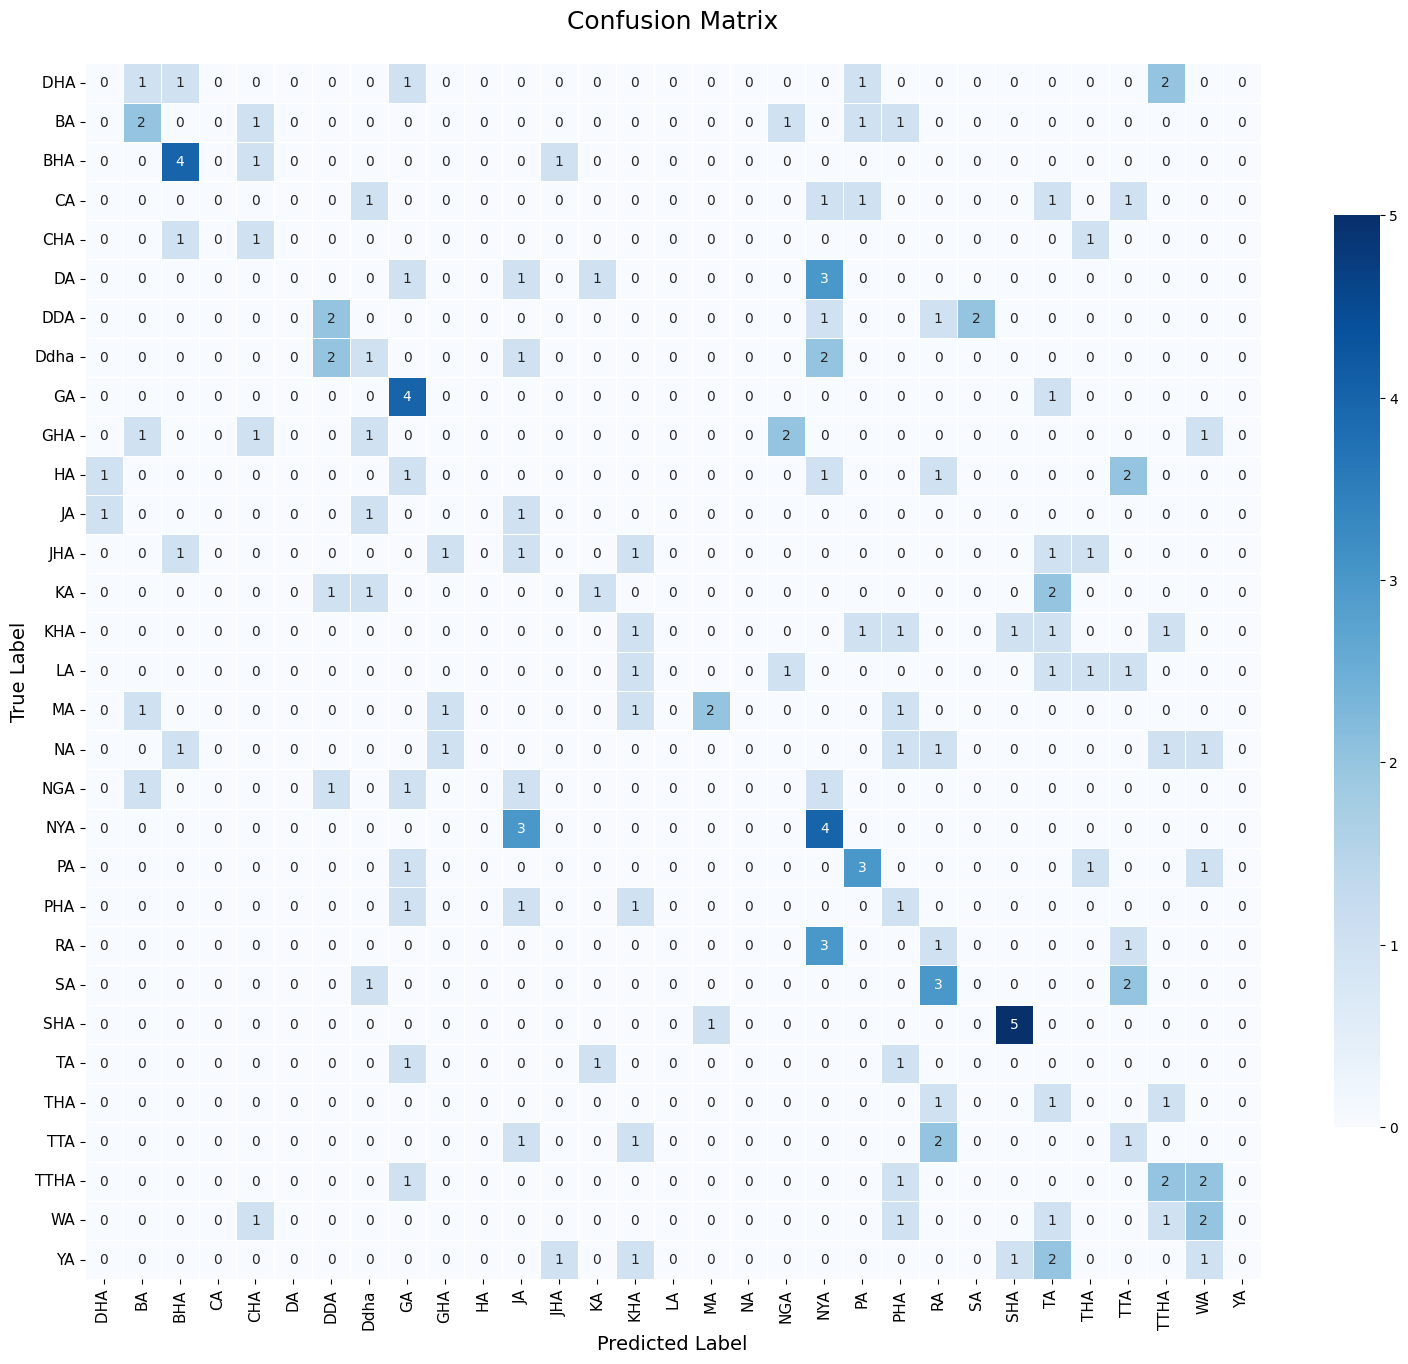


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [7]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "vit_small_patch16_dinov3"

print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()



print(f"Using device: {device}")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  mobilenetv4_conv_small.e2400_r224_in1k


model.safetensors:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Model: mobilenetv4_conv_small.e2400_r224_in1k
Trainable parameters: 1,271,071
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.69it/s]


Train Loss: 4.9969 | Acc: 7.89%
Val   Loss: 4.2153 | Acc: 16.95%
✅ Best model saved! Val Acc: 16.95%

Epoch 2/200


...

Train Loss: 0.7163 | Acc: 79.11%
Val   Loss: 1.1956 | Acc: 70.34%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 20.62it/s]


Train Loss: 0.6902 | Acc: 80.10%
Val   Loss: 1.1782 | Acc: 70.34%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 20.29it/s]


Train Loss: 0.8275 | Acc: 77.47%
Val   Loss: 1.1256 | Acc: 71.19%

Training finished! Best Validation Accuracy: 74.58%


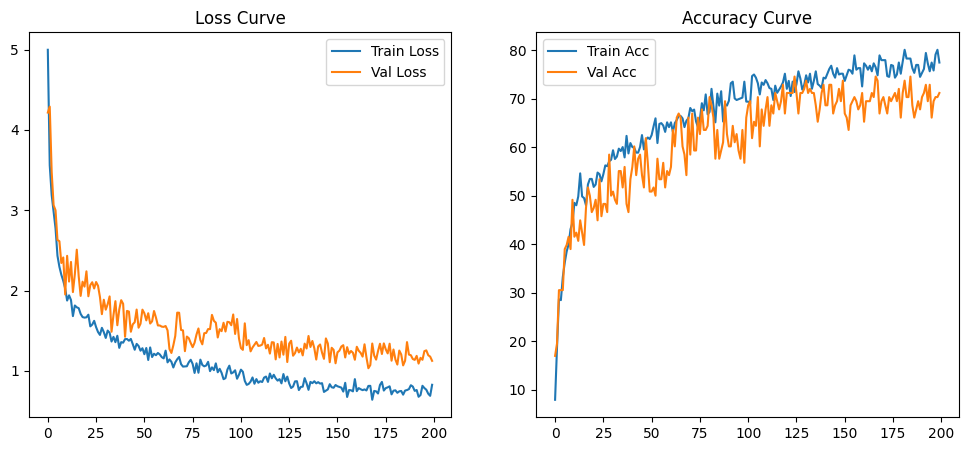

Test: 100%|██████████| 11/11 [00:00<00:00, 22.07it/s]



Final Test Accuracy: 70.48%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 22.16it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     0.7500    1.0000    0.8571         6
          BA     0.7143    0.8333    0.7692         6
         BHA     1.0000    0.8333    0.9091         6
          CA     0.7143    1.0000    0.8333         5
         CHA     0.4000    0.6667    0.5000         3
          DA     0.7143    0.8333    0.7692         6
         DDA     0.8333    0.8333    0.8333         6
        Ddha     1.0000    0.8333    0.9091         6
          GA     0.8000    0.8000    0.8000         5
         GHA     0.5000    0.3333    0.4000         6
          HA     0.8333    0.8333    0.8333         6
          JA     1.0000    0.6667    0.8000         3
         JHA     0.8571    1.0000    0.9231         6
          KA     1.0000    0.4000    0.5714         5
         KHA     0.6667    0.6667    0.6667         6
          LA     0.7500    0.6000    0.6667         5
          MA     0.8000    0.6667    0.7273         6
   

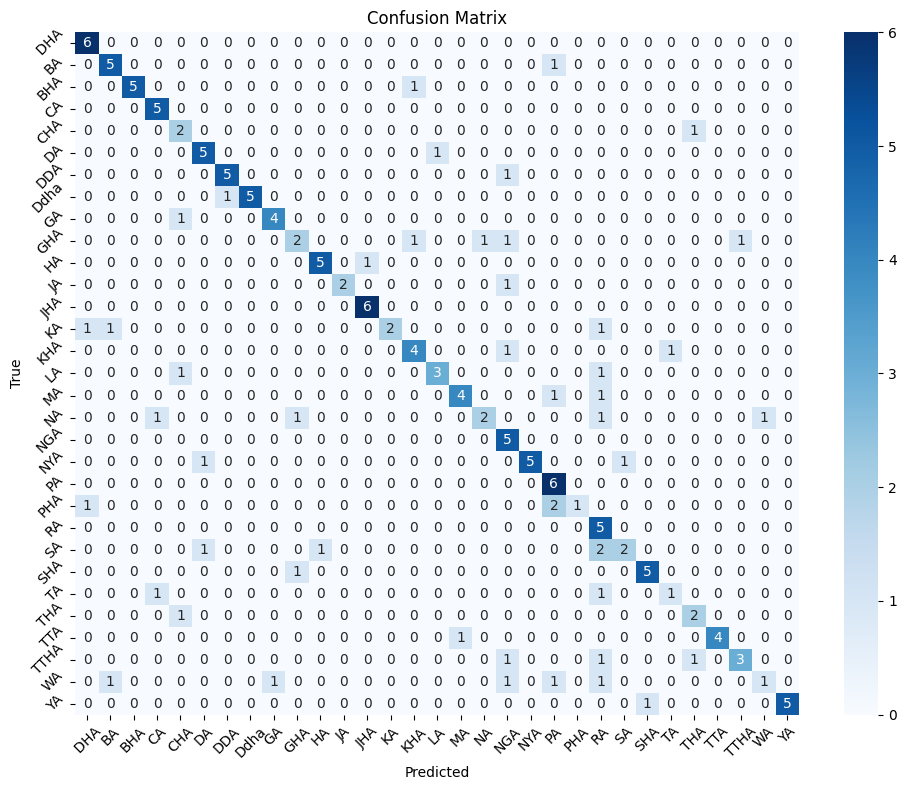

Using device: cuda
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_mobilenetv4_conv_small.e2400_r224_in1k.pth

FINAL TEST METRICS
Top-1 Accuracy : 70.4819%
Top-5 Accuracy : 92.1687%
Overall Accuracy: 70.4819%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     0.7500    1.0000    0.8571         6
          BA     0.7143    0.8333    0.7692         6
         BHA     1.0000    0.8333    0.9091         6
          CA     0.7143    1.0000    0.8333         5
         CHA     0.4000    0.6667    0.5000         3
          DA     0.7143    0.8333    0.7692         6
         DDA     0.8333    0.8333    0.8333         6
        Ddha     1.0000    0.8333    0.9091         6
          GA     0.8000    0.8000    0.8000         5
         GHA     0.5000    0.3333    0.4000         6
          HA     0.8333    0.8333    0.8333         6
          JA     1.0000    0.6667    0.8000         3
         JHA     0.8571    1.0000

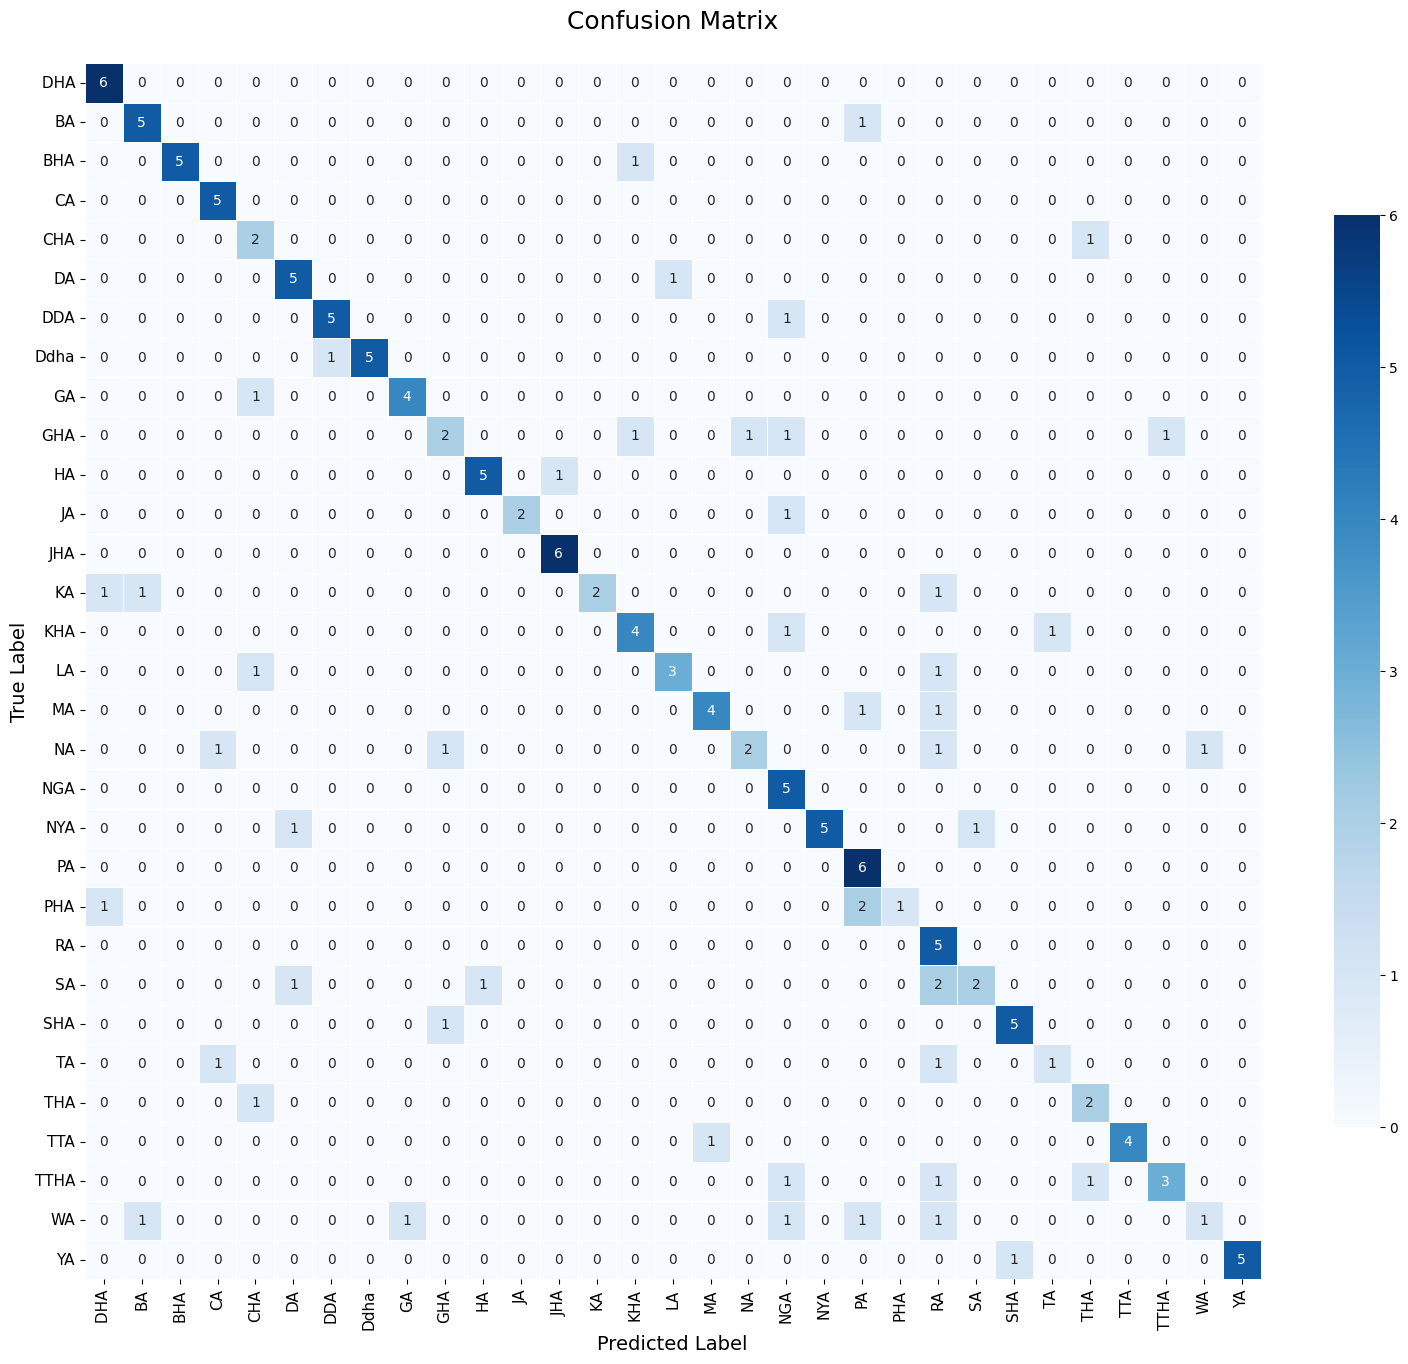


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [8]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "mobilenetv4_conv_small.e2400_r224_in1k"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Using device: {device}")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

In [9]:
# get model names
mobileone_models = timm.list_models("*mobileone*")
efficientformer_models = timm.list_models("*efficientformer*")

all_models = list(mobileone_models) + list(efficientformer_models)

model_params = []

for name in all_models:
    try:
        model = timm.create_model(name, pretrained=False)
        params = sum(p.numel() for p in model.parameters())
        model_params.append((name, params))
    except:
        continue

# sort by parameter count (ascending)
model_params.sort(key=lambda x: x[1])

print("\n=== Models sorted by parameter size (small → large) ===\n")
for name, params in model_params:
    print(f"{name:35s} : {params/1e6:.2f} M")


=== Models sorted by parameter size (small → large) ===

efficientformerv2_s0                : 3.60 M
mobileone_s1                        : 4.83 M
mobileone_s0                        : 5.29 M
efficientformerv2_s1                : 6.19 M
mobileone_s2                        : 7.88 M
mobileone_s3                        : 10.17 M
efficientformer_l1                  : 12.29 M
efficientformerv2_s2                : 12.71 M
mobileone_s4                        : 14.95 M
efficientformerv2_l                 : 26.32 M
efficientformer_l3                  : 31.41 M
efficientformer_l7                  : 82.23 M


Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  efficientformerv2_s0


model.safetensors:   0%|          | 0.00/14.7M [00:00<?, ?B/s]

Model: efficientformerv2_s0
Trainable parameters: 1,338,878
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.28it/s]


Train Loss: 3.4052 | Acc: 6.58%
Val   Loss: 3.4092 | Acc: 6.78%
✅ Best model saved! Val Acc: 6.78%

Epoch 2/200


...

Train Loss: 0.0119 | Acc: 99.51%
Val   Loss: 0.1271 | Acc: 98.31%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.13it/s]


Train Loss: 0.0110 | Acc: 99.67%
Val   Loss: 0.1045 | Acc: 98.31%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 15.62it/s]


Train Loss: 0.0256 | Acc: 99.01%
Val   Loss: 0.1255 | Acc: 98.31%

Training finished! Best Validation Accuracy: 99.15%


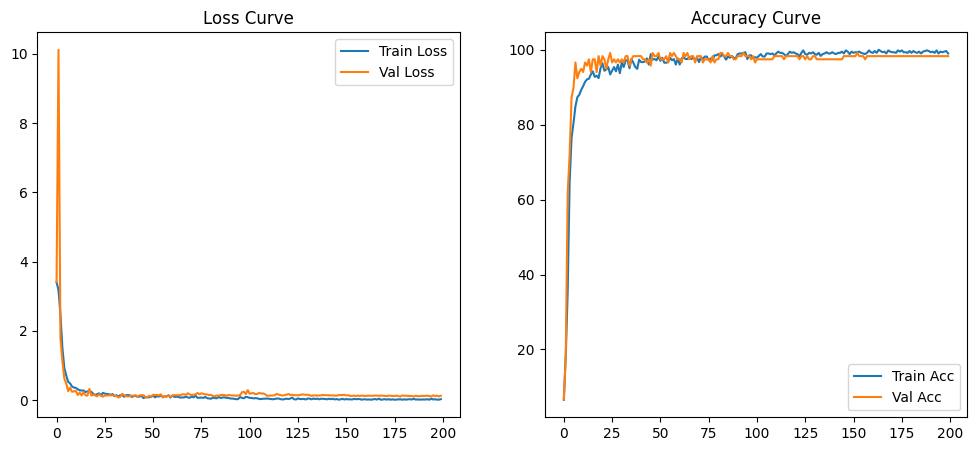

Test: 100%|██████████| 11/11 [00:00<00:00, 20.34it/s]



Final Test Accuracy: 98.19%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 20.19it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000         6
          KA     1.0000    1.0000    1.0000         5
         KHA     1.0000    1.0000    1.0000         6
          LA     1.0000    0.6000    0.7500         5
          MA     1.0000    1.0000    1.0000         6
   

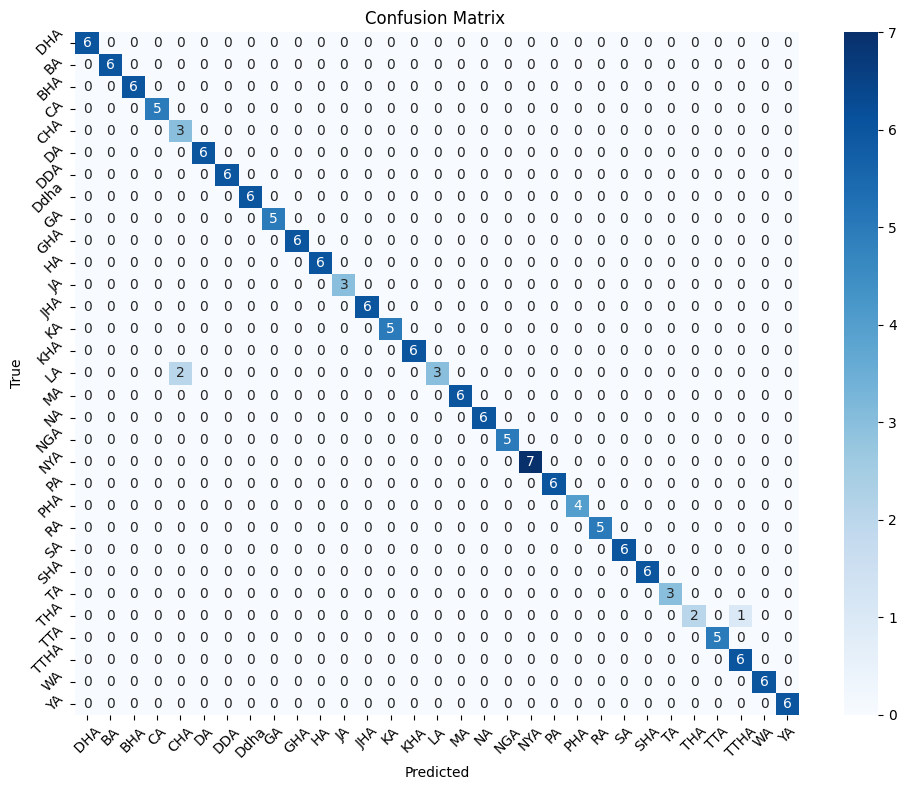

Using device: cuda
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_efficientformerv2_s0.pth

FINAL TEST METRICS
Top-1 Accuracy : 98.1928%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 98.1928%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000       

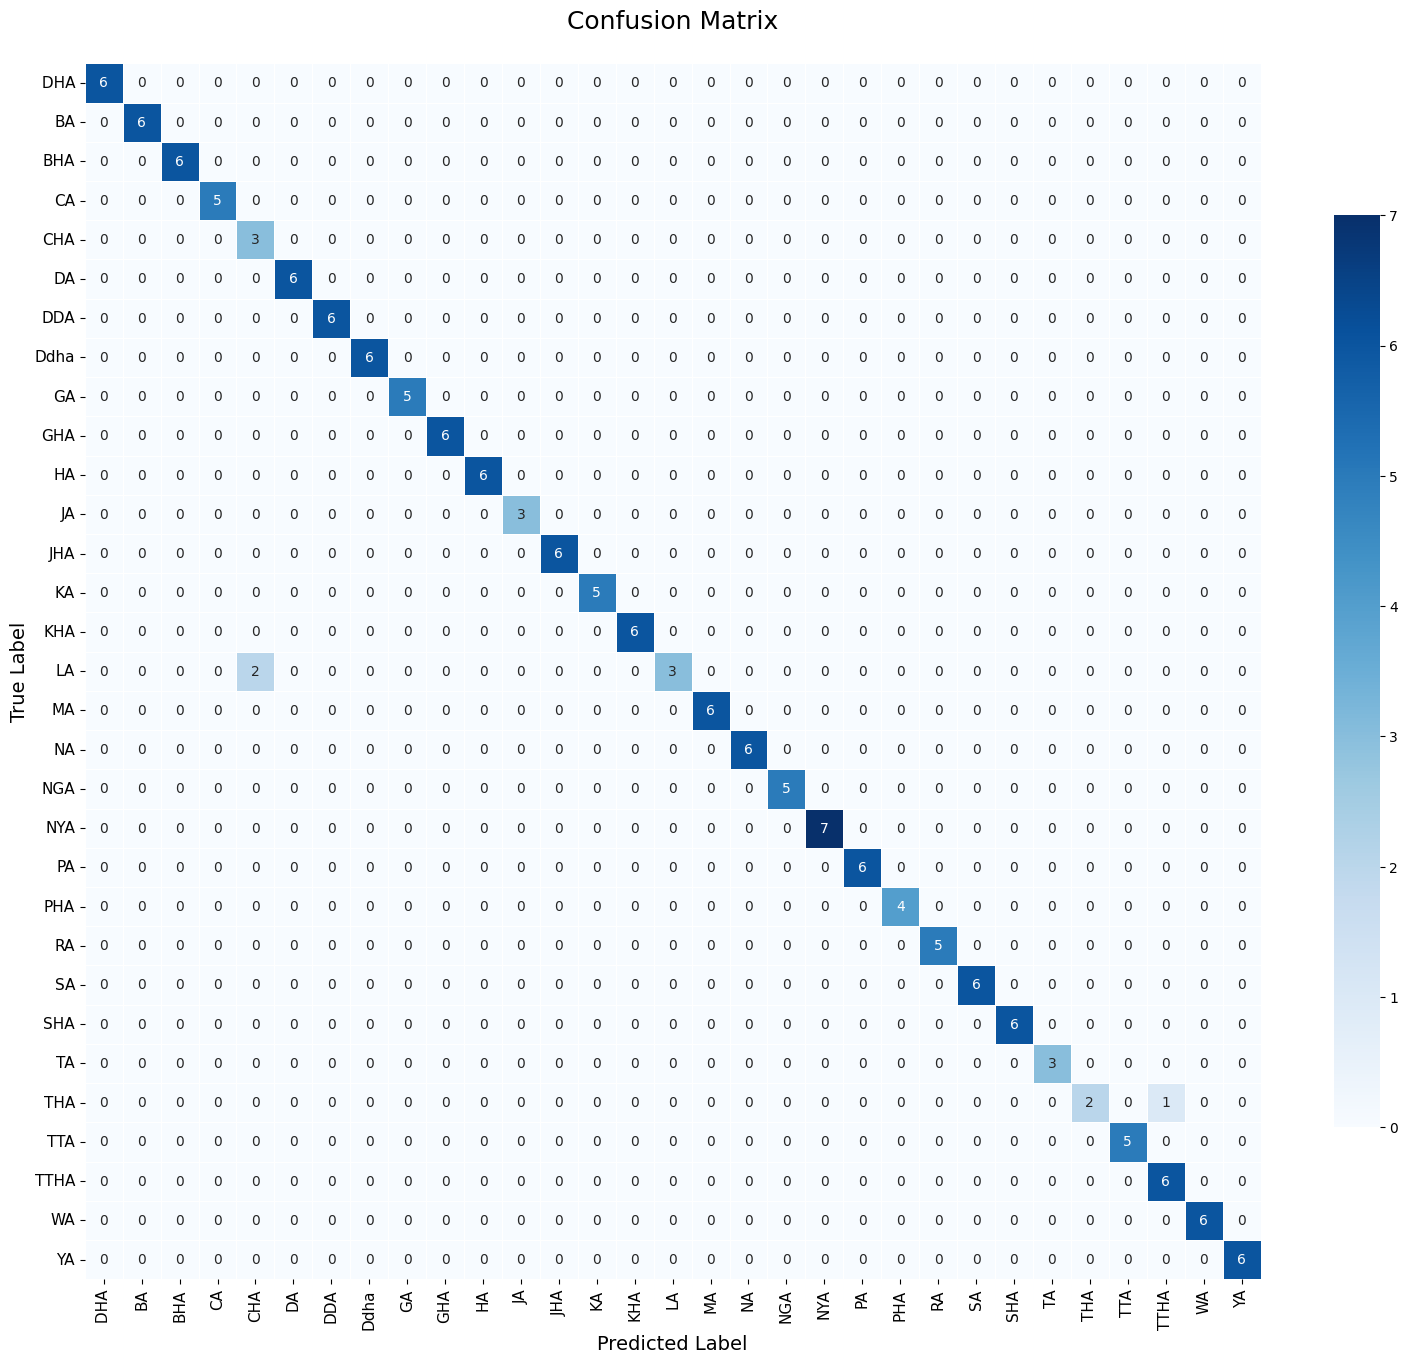


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [10]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "efficientformerv2_s0"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


print(f"Using device: {device}")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  mobileone_s1


model.safetensors:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

Model: mobileone_s1
Trainable parameters: 39,711
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 16.68it/s]


Train Loss: 3.5679 | Acc: 4.28%
Val   Loss: 3.4303 | Acc: 10.17%
✅ Best model saved! Val Acc: 10.17%

Epoch 2/200


...

Train Loss: 0.9774 | Acc: 72.86%
Val   Loss: 1.4221 | Acc: 66.10%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 16.65it/s]


Train Loss: 1.0935 | Acc: 68.59%
Val   Loss: 1.3352 | Acc: 64.41%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.53it/s]


Train Loss: 1.0114 | Acc: 72.04%
Val   Loss: 1.4179 | Acc: 66.10%

Training finished! Best Validation Accuracy: 69.49%


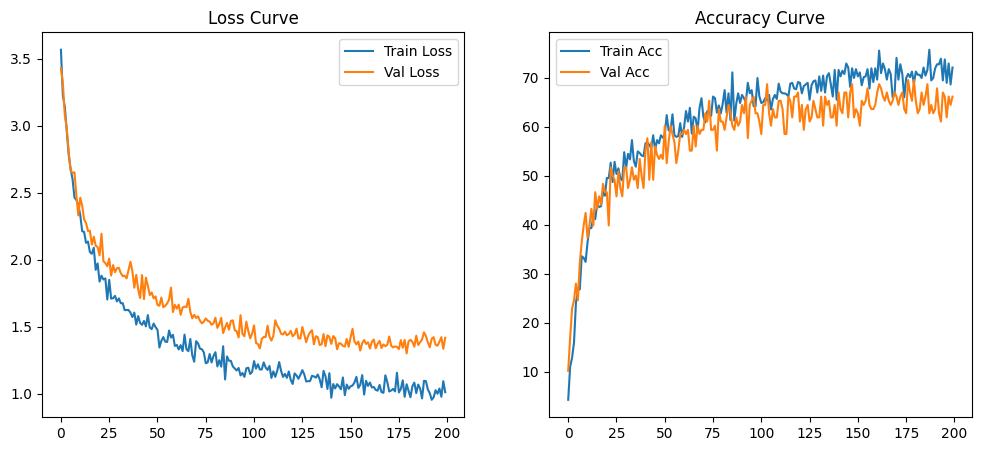

Test: 100%|██████████| 11/11 [00:00<00:00, 18.53it/s]



Final Test Accuracy: 70.48%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 19.06it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le


CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     0.4615    1.0000    0.6316         6
          BA     0.7500    0.5000    0.6000         6
         BHA     1.0000    0.8333    0.9091         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.7500    1.0000    0.8571         3
          DA     0.7500    1.0000    0.8571         6
         DDA     0.5455    1.0000    0.7059         6
        Ddha     0.8333    0.8333    0.8333         6
          GA     0.6250    1.0000    0.7692         5
         GHA     0.6667    0.3333    0.4444         6
          HA     0.6250    0.8333    0.7143         6
          JA     0.0000    0.0000    0.0000         3
         JHA     1.0000    0.8333    0.9091         6
          KA     1.0000    0.2000    0.3333         5
         KHA     1.0000    0.8333    0.9091         6
          LA     0.6000    0.6000    0.6000         5
          MA     1.0000    0.6667    0.8000         6
   

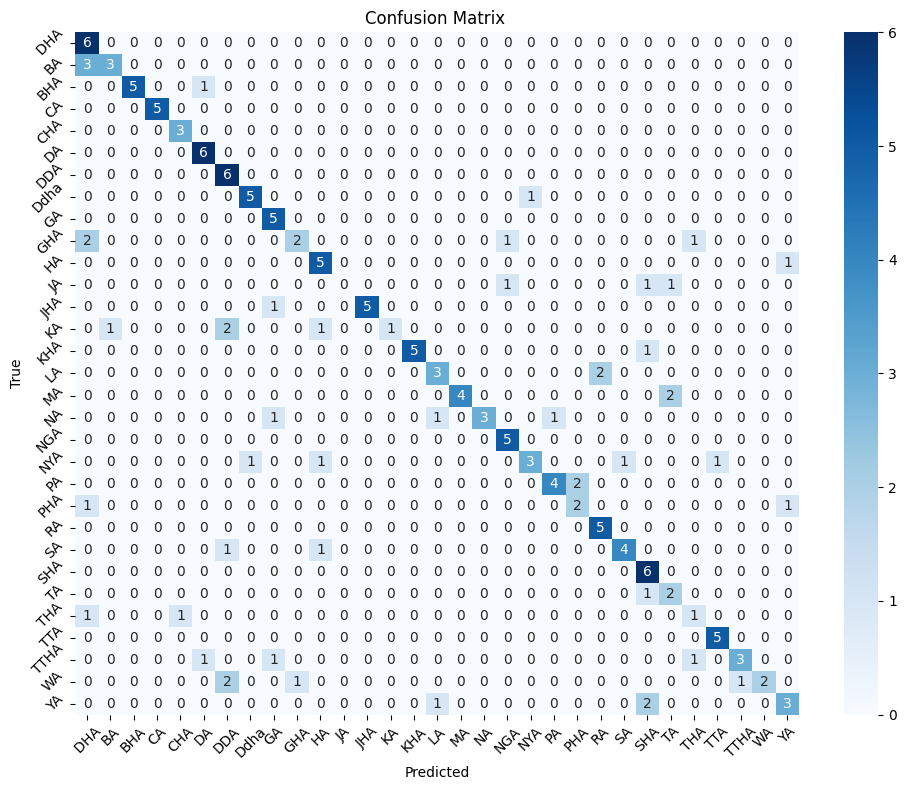

Using device: cuda
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_mobileone_s1.pth

FINAL TEST METRICS
Top-1 Accuracy : 70.4819%
Top-5 Accuracy : 92.7711%
Overall Accuracy: 70.4819%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     0.4615    1.0000    0.6316         6
          BA     0.7500    0.5000    0.6000         6
         BHA     1.0000    0.8333    0.9091         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.7500    1.0000    0.8571         3
          DA     0.7500    1.0000    0.8571         6
         DDA     0.5455    1.0000    0.7059         6
        Ddha     0.8333    0.8333    0.8333         6
          GA     0.6250    1.0000    0.7692         5
         GHA     0.6667    0.3333    0.4444         6
          HA     0.6250    0.8333    0.7143         6
          JA     0.0000    0.0000    0.0000         3
         JHA     1.0000    0.8333    0.9091         6
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


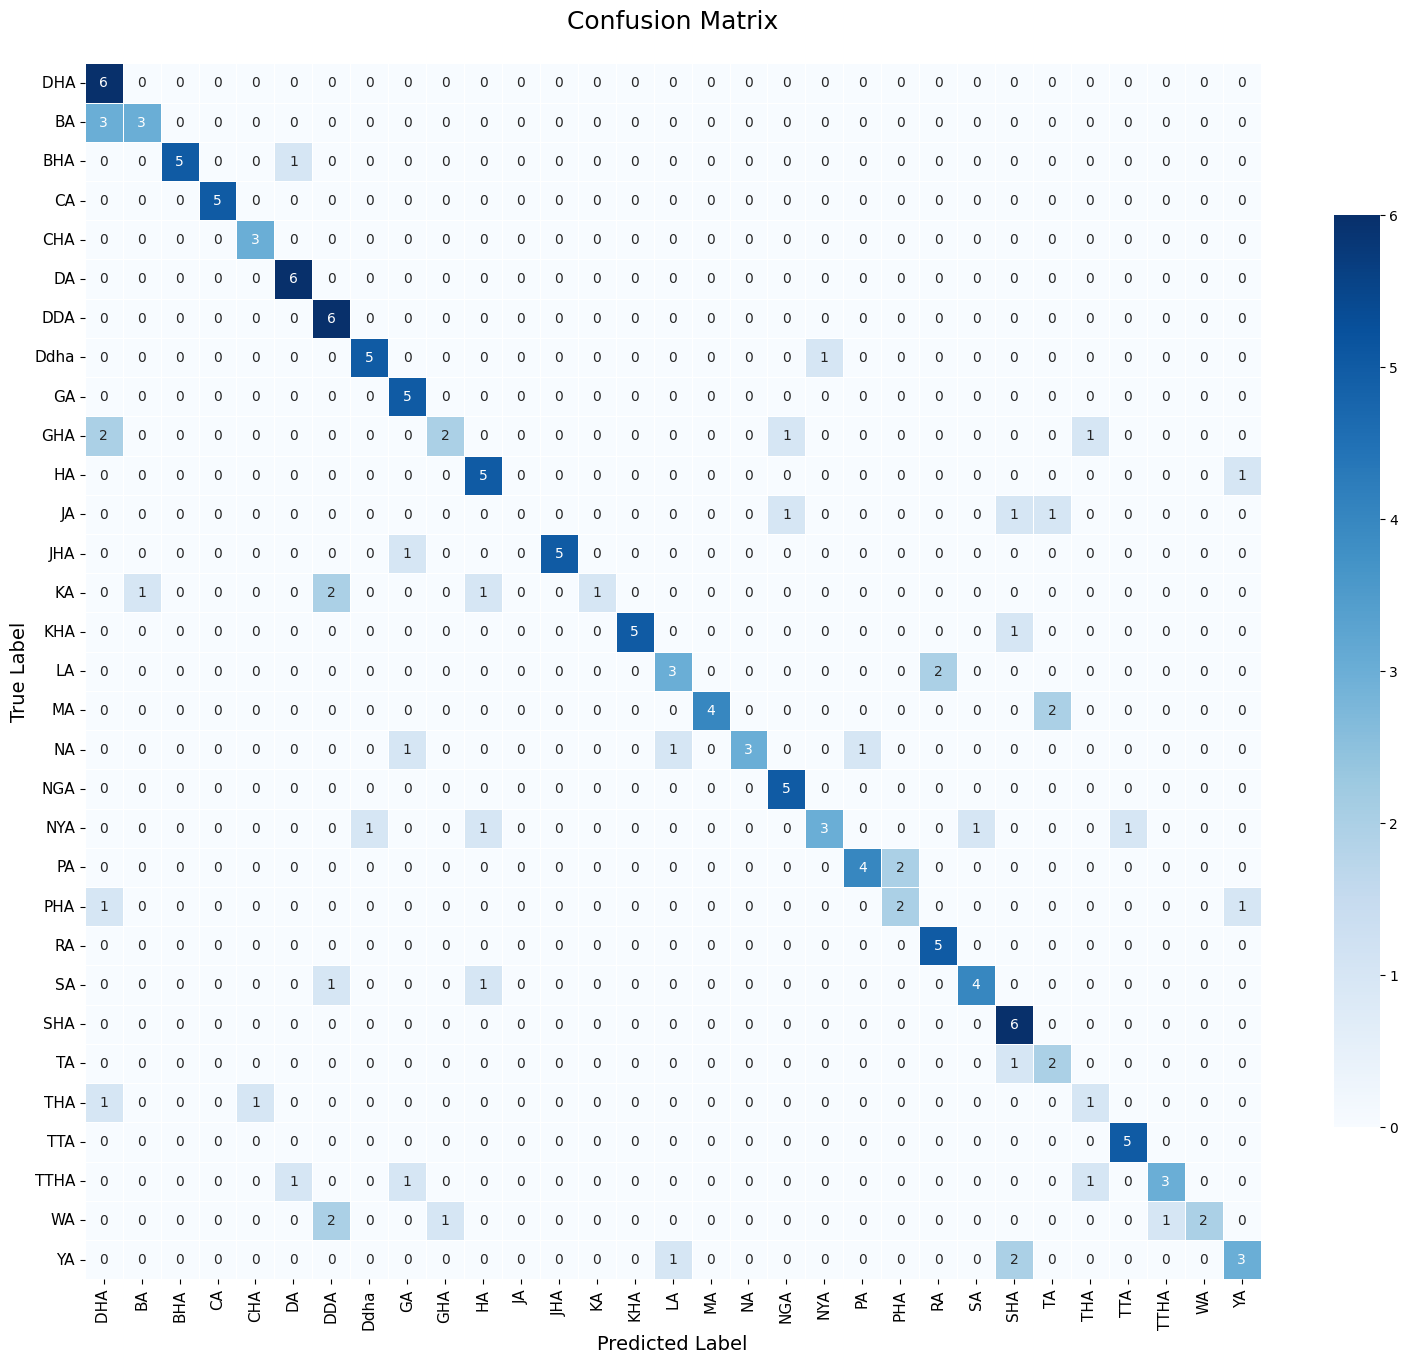


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [11]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "mobileone_s1"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


print(f"Using device: {device}")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

In [12]:
# =========================
# BROADER MODEL FAMILIES
# =========================
model_patterns = [
    "*efficientformer*",
    "*tinynet*",
    "*edgenext*",
    "*fastvit*",
    "*efficientvit*",
    "*tiny_vit*",
]

# =========================
# COLLECT MODELS
# =========================
all_models = []
for pattern in model_patterns:
    all_models.extend(timm.list_models(pattern))

all_models = sorted(set(all_models))  # remove duplicates

# =========================
# PARAMETER COUNTING
# =========================
model_params = []

for name in all_models:
    try:
        model = timm.create_model(name, pretrained=False)
        params = sum(p.numel() for p in model.parameters())
        model_params.append((name, params))
    except Exception:
        continue

# =========================
# SORT BY SIZE
# =========================
model_params.sort(key=lambda x: x[1])

print("\n=== Lightweight Models in TIMM (sorted by params) ===\n")
for name, params in model_params:
    print(f"{name:45s} : {params/1e6:.2f} M")


=== Lightweight Models in TIMM (sorted by params) ===

edgenext_xx_small                             : 1.33 M
tinynet_e                                     : 2.04 M
edgenext_x_small                              : 2.34 M
tinynet_d                                     : 2.34 M
efficientvit_m0                               : 2.35 M
tinynet_c                                     : 2.46 M
efficientvit_m1                               : 2.98 M
efficientvit_b0                               : 3.41 M
efficientformerv2_s0                          : 3.60 M
tinynet_b                                     : 3.73 M
fastvit_t8                                    : 4.03 M
efficientvit_m2                               : 4.19 M
edgenext_small                                : 5.59 M
efficientformerv2_s1                          : 6.19 M
tinynet_a                                     : 6.19 M
efficientvit_m3                               : 6.90 M
fastvit_t12                                   : 7.55 M
edgenext_

In [13]:
selected_variants = [
    "edgenext_xx_small", "tinynet_e", "efficientvit_m0","efficientformerv2_s0","fastvit_t8","tiny_vit_5m_224","efficientformer_l1",
]
print(selected_variants)

['edgenext_xx_small', 'tinynet_e', 'efficientvit_m0', 'efficientformerv2_s0', 'fastvit_t8', 'tiny_vit_5m_224', 'efficientformer_l1']


Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  edgenext_xx_small


model.safetensors:   0%|          | 0.00/5.32M [00:00<?, ?B/s]

Model: edgenext_xx_small
Trainable parameters: 879,991
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]


Train Loss: 3.4807 | Acc: 3.62%
Val   Loss: 3.4335 | Acc: 5.93%
✅ Best model saved! Val Acc: 5.93%

Epoch 2/200


...

Train Loss: 0.0143 | Acc: 99.67%
Val   Loss: 0.0837 | Acc: 99.15%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.34it/s]


Train Loss: 0.0115 | Acc: 99.18%
Val   Loss: 0.0837 | Acc: 99.15%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.44it/s]


Train Loss: 0.0155 | Acc: 99.67%
Val   Loss: 0.0837 | Acc: 99.15%

Training finished! Best Validation Accuracy: 99.15%


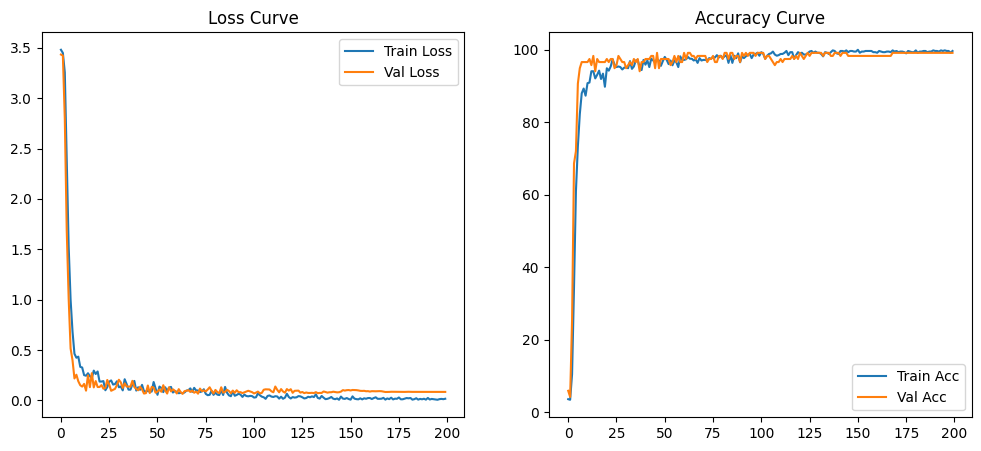

Test: 100%|██████████| 11/11 [00:00<00:00, 20.83it/s]



Final Test Accuracy: 99.40%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 20.88it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     1.0000    1.0000    1.0000         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000         6
          KA     1.0000    1.0000    1.0000         5
         KHA     1.0000    1.0000    1.0000         6
          LA     1.0000    1.0000    1.0000         5
          MA     1.0000    1.0000    1.0000         6
   

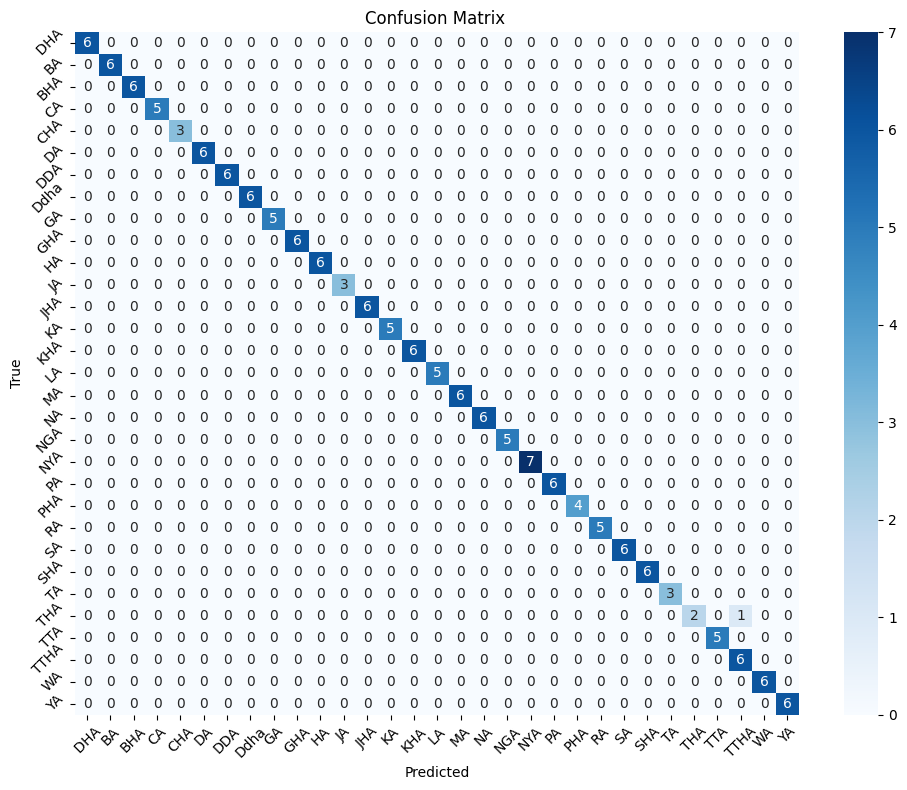

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_edgenext_xx_small.pth

FINAL TEST METRICS
Top-1 Accuracy : 99.3976%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 99.3976%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     1.0000    1.0000    1.0000         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    

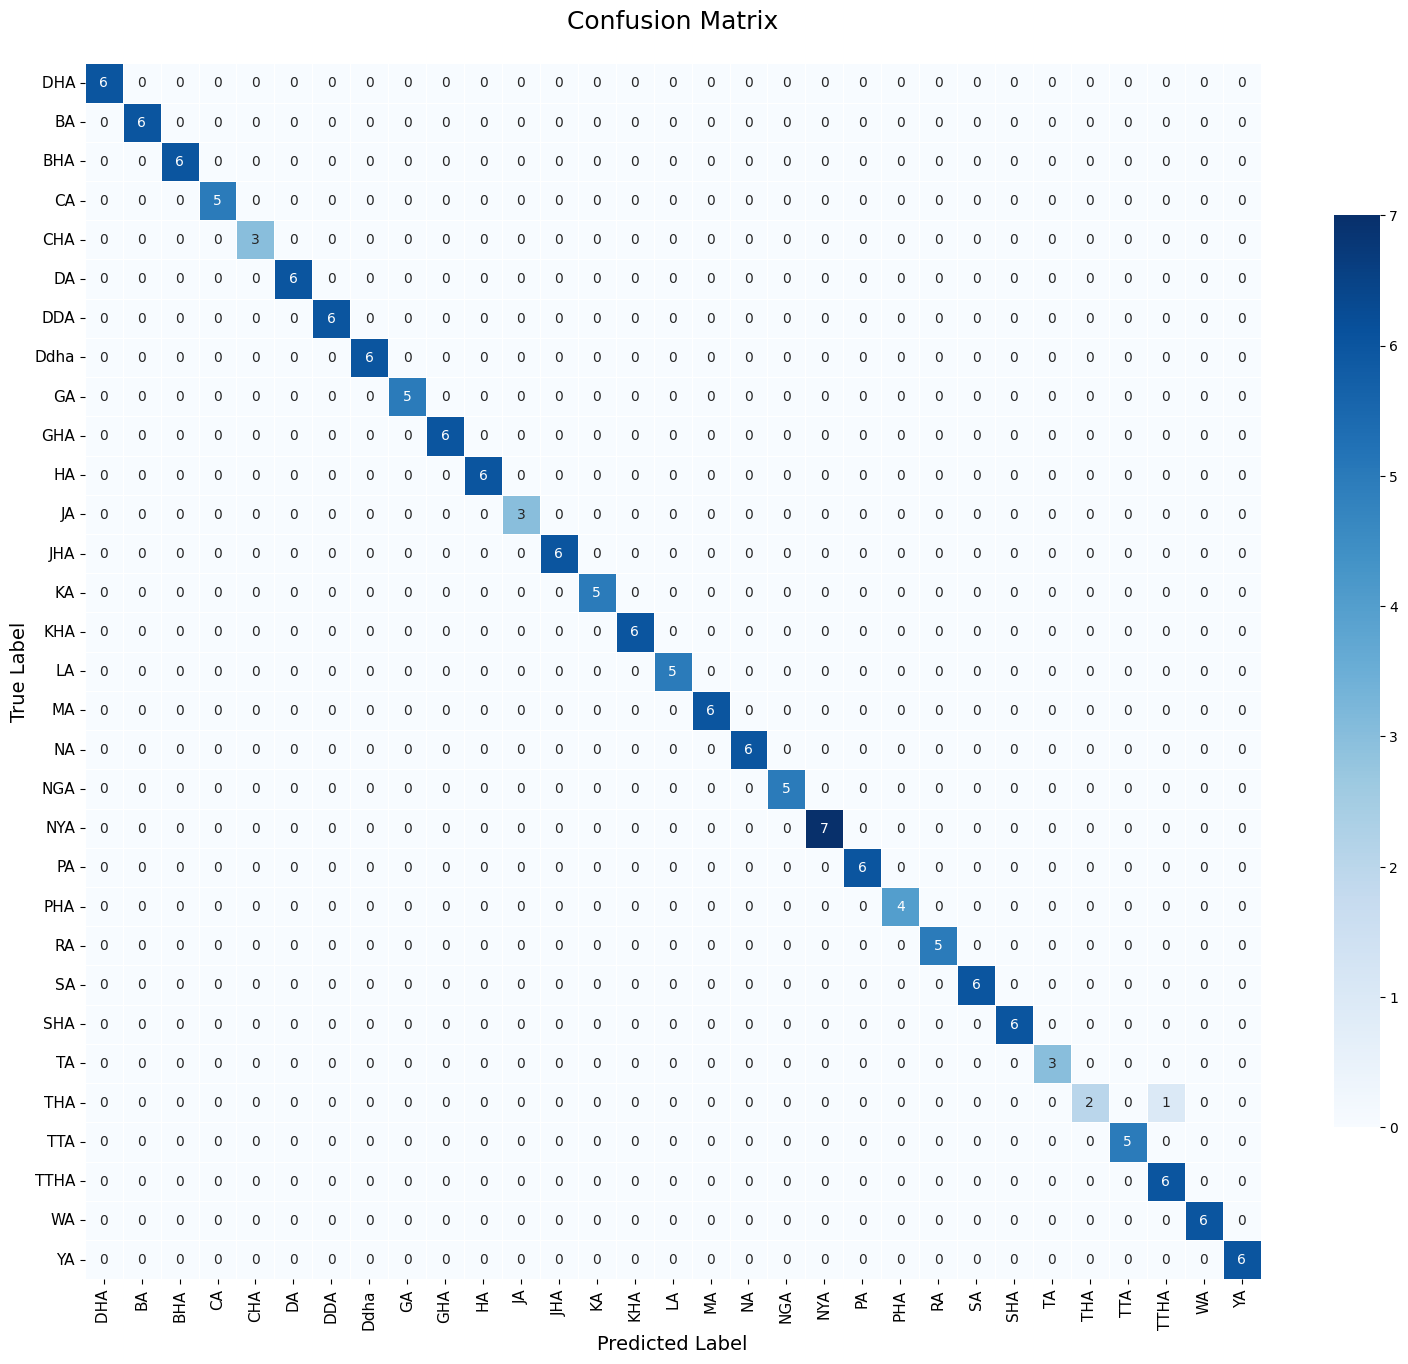


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [14]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "edgenext_xx_small"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  tinynet_e


model.safetensors:   0%|          | 0.00/8.25M [00:00<?, ?B/s]

Model: tinynet_e
Trainable parameters: 244,511
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.96it/s]


Train Loss: 3.8146 | Acc: 4.44%
Val   Loss: 3.8340 | Acc: 5.93%
✅ Best model saved! Val Acc: 5.93%

Epoch 2/200


...

Train Loss: 0.7321 | Acc: 76.97%
Val   Loss: 1.3069 | Acc: 61.02%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 19.12it/s]


Train Loss: 0.6931 | Acc: 78.95%
Val   Loss: 1.4667 | Acc: 56.78%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 20.02it/s]


Train Loss: 0.7216 | Acc: 79.93%
Val   Loss: 1.2877 | Acc: 61.02%

Training finished! Best Validation Accuracy: 64.41%


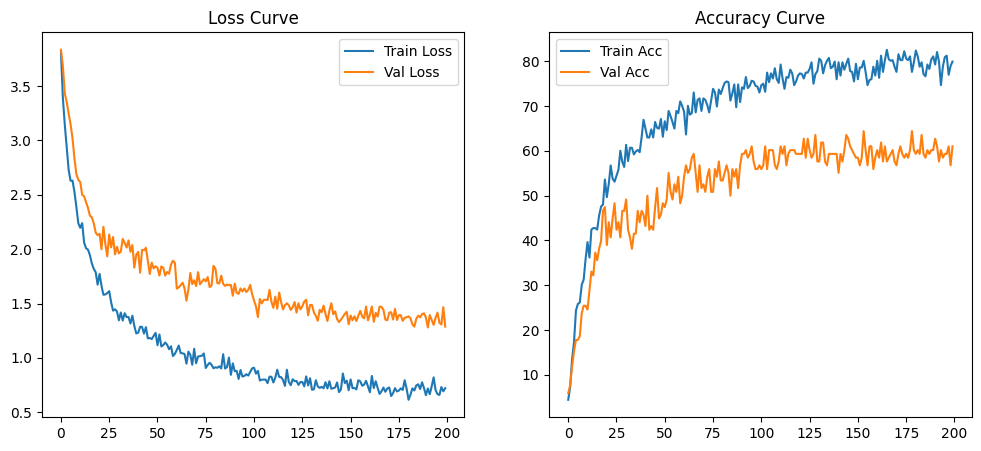

Test: 100%|██████████| 11/11 [00:00<00:00, 21.65it/s]



Final Test Accuracy: 62.65%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 22.36it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     0.8000    0.6667    0.7273         6
          BA     1.0000    0.5000    0.6667         6
         BHA     1.0000    1.0000    1.0000         6
          CA     0.6667    0.8000    0.7273         5
         CHA     0.2500    0.6667    0.3636         3
          DA     0.3125    0.8333    0.4545         6
         DDA     0.7500    1.0000    0.8571         6
        Ddha     1.0000    0.6667    0.8000         6
          GA     0.8000    0.8000    0.8000         5
         GHA     0.6667    0.6667    0.6667         6
          HA     1.0000    0.8333    0.9091         6
          JA     0.6667    0.6667    0.6667         3
         JHA     1.0000    0.3333    0.5000         6
          KA     0.4000    0.4000    0.4000         5
         KHA     1.0000    0.3333    0.5000         6
          LA     0.3333    0.4000    0.3636         5
          MA     1.0000    0.1667    0.2857         6
   

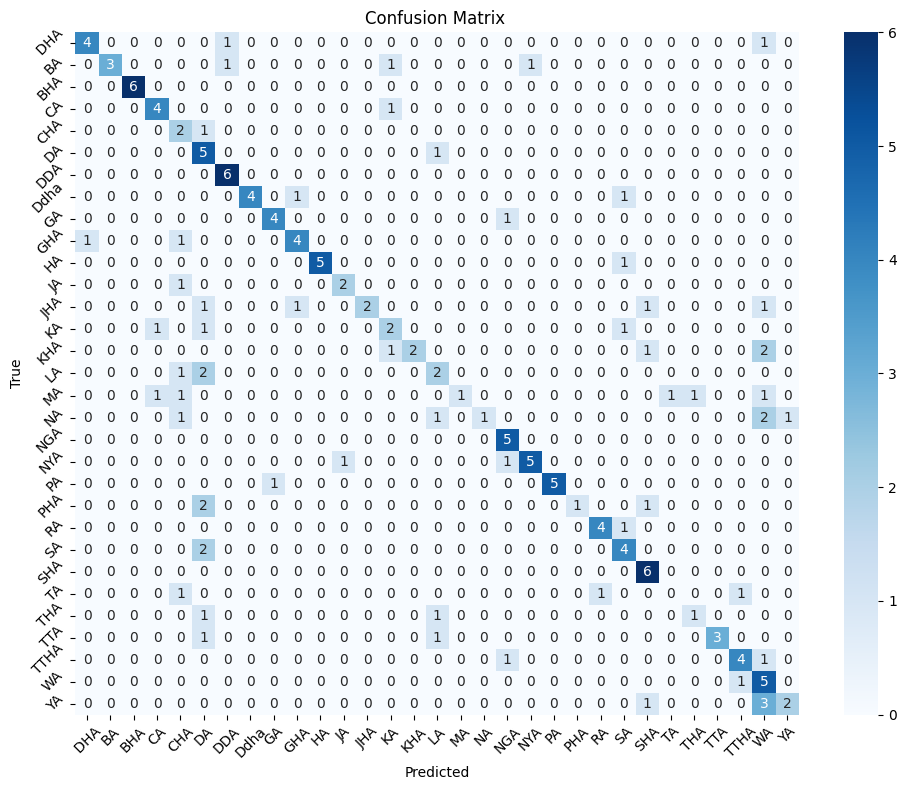

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_tinynet_e.pth

FINAL TEST METRICS
Top-1 Accuracy : 62.6506%
Top-5 Accuracy : 87.3494%
Overall Accuracy: 62.6506%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     0.8000    0.6667    0.7273         6
          BA     1.0000    0.5000    0.6667         6
         BHA     1.0000    1.0000    1.0000         6
          CA     0.6667    0.8000    0.7273         5
         CHA     0.2500    0.6667    0.3636         3
          DA     0.3125    0.8333    0.4545         6
         DDA     0.7500    1.0000    0.8571         6
        Ddha     1.0000    0.6667    0.8000         6
          GA     0.8000    0.8000    0.8000         5
         GHA     0.6667    0.6667    0.6667         6
          HA     1.0000    0.8333    0.9091         6
          JA     0.6667    0.6667    0.6667         3
         JHA     1.0000    0.3333    0.5000   

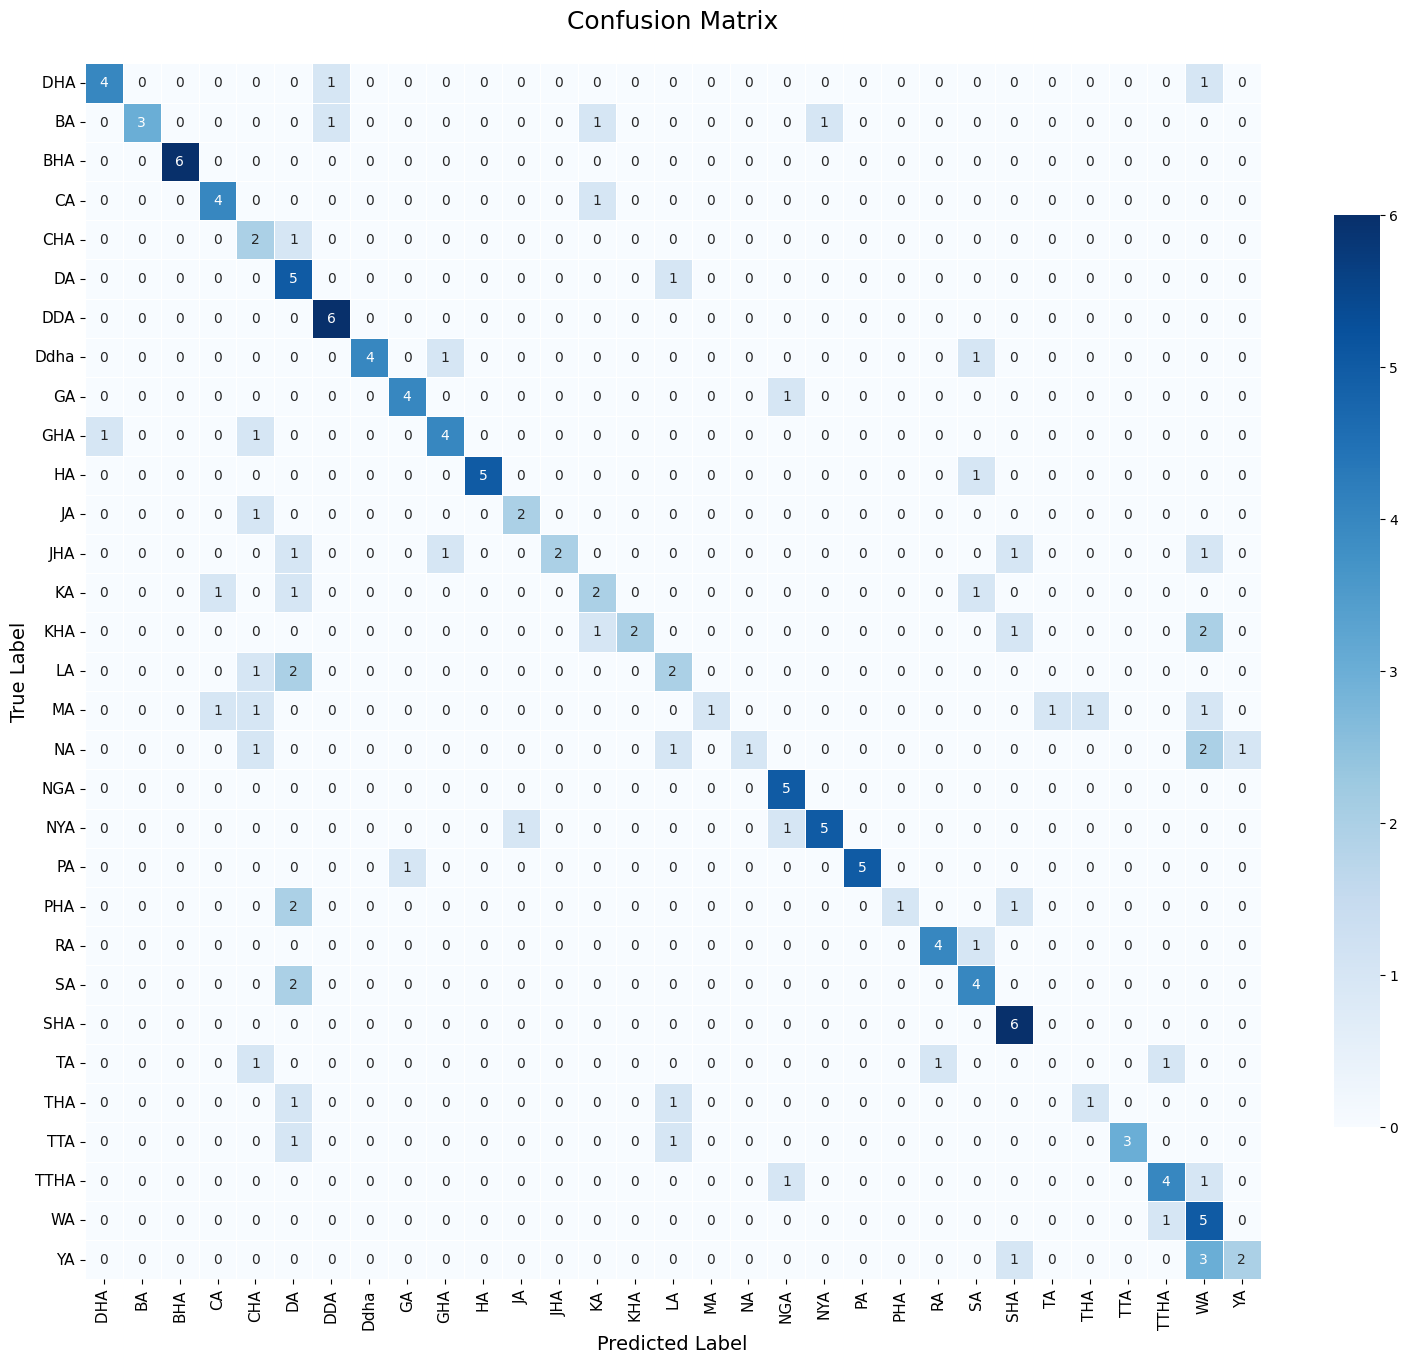


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [15]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "tinynet_e"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  efficientvit_m0


model.safetensors:   0%|          | 0.00/9.59M [00:00<?, ?B/s]

Model: efficientvit_m0
Trainable parameters: 171,167
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00,  9.77it/s]


Train Loss: 3.4313 | Acc: 3.95%
Val   Loss: 3.4317 | Acc: 5.93%
✅ Best model saved! Val Acc: 5.93%

Epoch 2/200


...

Train Loss: 1.5970 | Acc: 53.29%
Val   Loss: 1.5352 | Acc: 49.15%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 16.93it/s]


Train Loss: 1.5697 | Acc: 53.29%
Val   Loss: 1.5935 | Acc: 53.39%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.67it/s]


Train Loss: 1.5550 | Acc: 54.28%
Val   Loss: 1.5357 | Acc: 48.31%

Training finished! Best Validation Accuracy: 61.86%


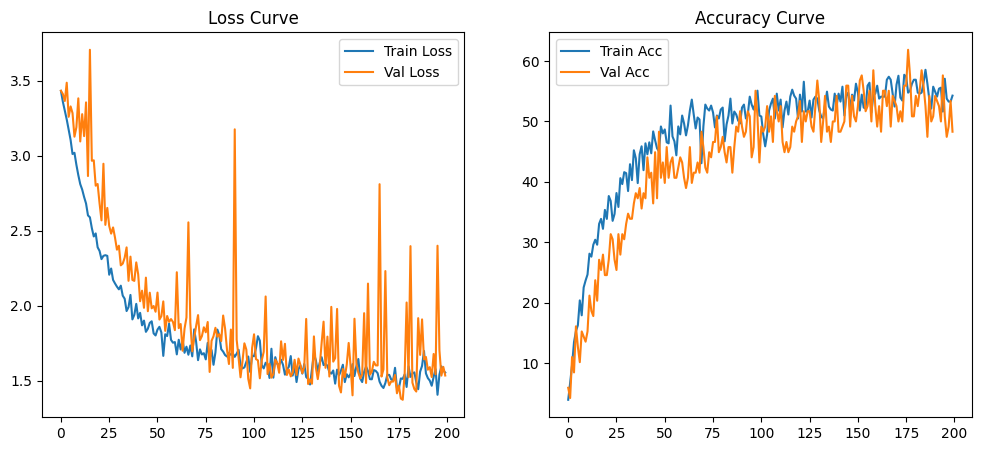

Test: 100%|██████████| 11/11 [00:00<00:00, 17.56it/s]



Final Test Accuracy: 60.24%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 18.30it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     0.4444    0.6667    0.5333         6
          BA     0.5000    0.1667    0.2500         6
         BHA     1.0000    0.5000    0.6667         6
          CA     0.6667    0.8000    0.7273         5
         CHA     0.2500    0.6667    0.3636         3
          DA     0.4000    0.6667    0.5000         6
         DDA     1.0000    0.8333    0.9091         6
        Ddha     0.7143    0.8333    0.7692         6
          GA     1.0000    0.6000    0.7500         5
         GHA     0.4000    0.3333    0.3636         6
          HA     0.7143    0.8333    0.7692         6
          JA     0.5000    1.0000    0.6667         3
         JHA     0.8333    0.8333    0.8333         6
          KA     0.7500    0.6000    0.6667         5
         KHA     1.0000    0.3333    0.5000         6
          LA     0.4000    0.4000    0.4000         5
          MA     0.6667    0.6667    0.6667         6
   

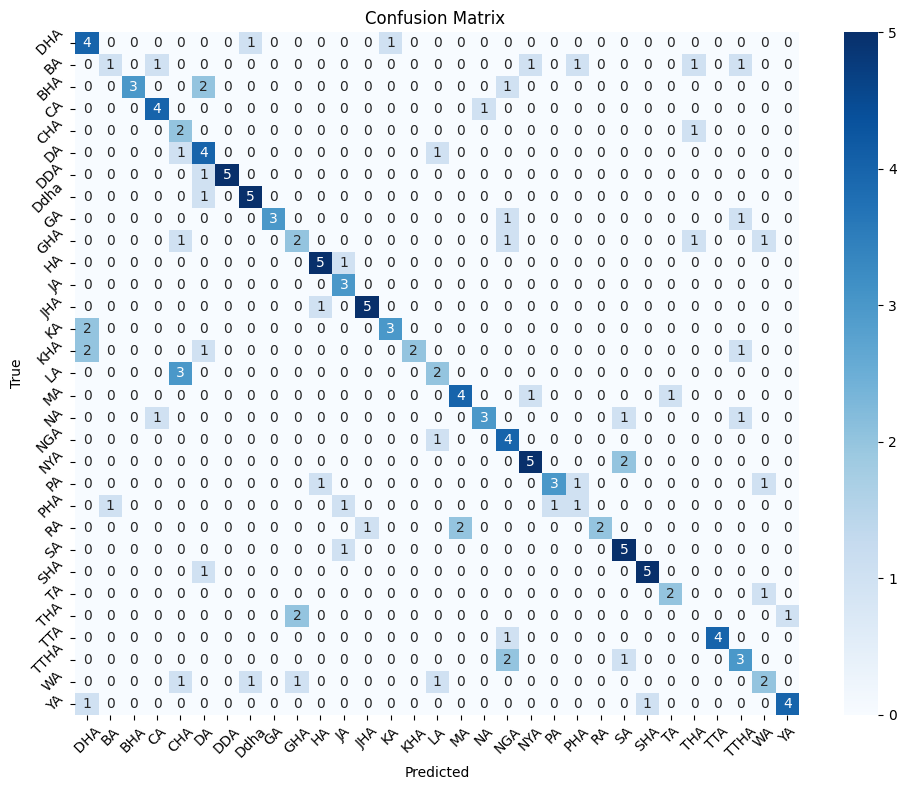

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_efficientvit_m0.pth

FINAL TEST METRICS
Top-1 Accuracy : 60.2410%
Top-5 Accuracy : 90.9639%
Overall Accuracy: 60.2410%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     0.4444    0.6667    0.5333         6
          BA     0.5000    0.1667    0.2500         6
         BHA     1.0000    0.5000    0.6667         6
          CA     0.6667    0.8000    0.7273         5
         CHA     0.2500    0.6667    0.3636         3
          DA     0.4000    0.6667    0.5000         6
         DDA     1.0000    0.8333    0.9091         6
        Ddha     0.7143    0.8333    0.7692         6
          GA     1.0000    0.6000    0.7500         5
         GHA     0.4000    0.3333    0.3636         6
          HA     0.7143    0.8333    0.7692         6
          JA     0.5000    1.0000    0.6667         3
         JHA     0.8333    0.8333    0.8

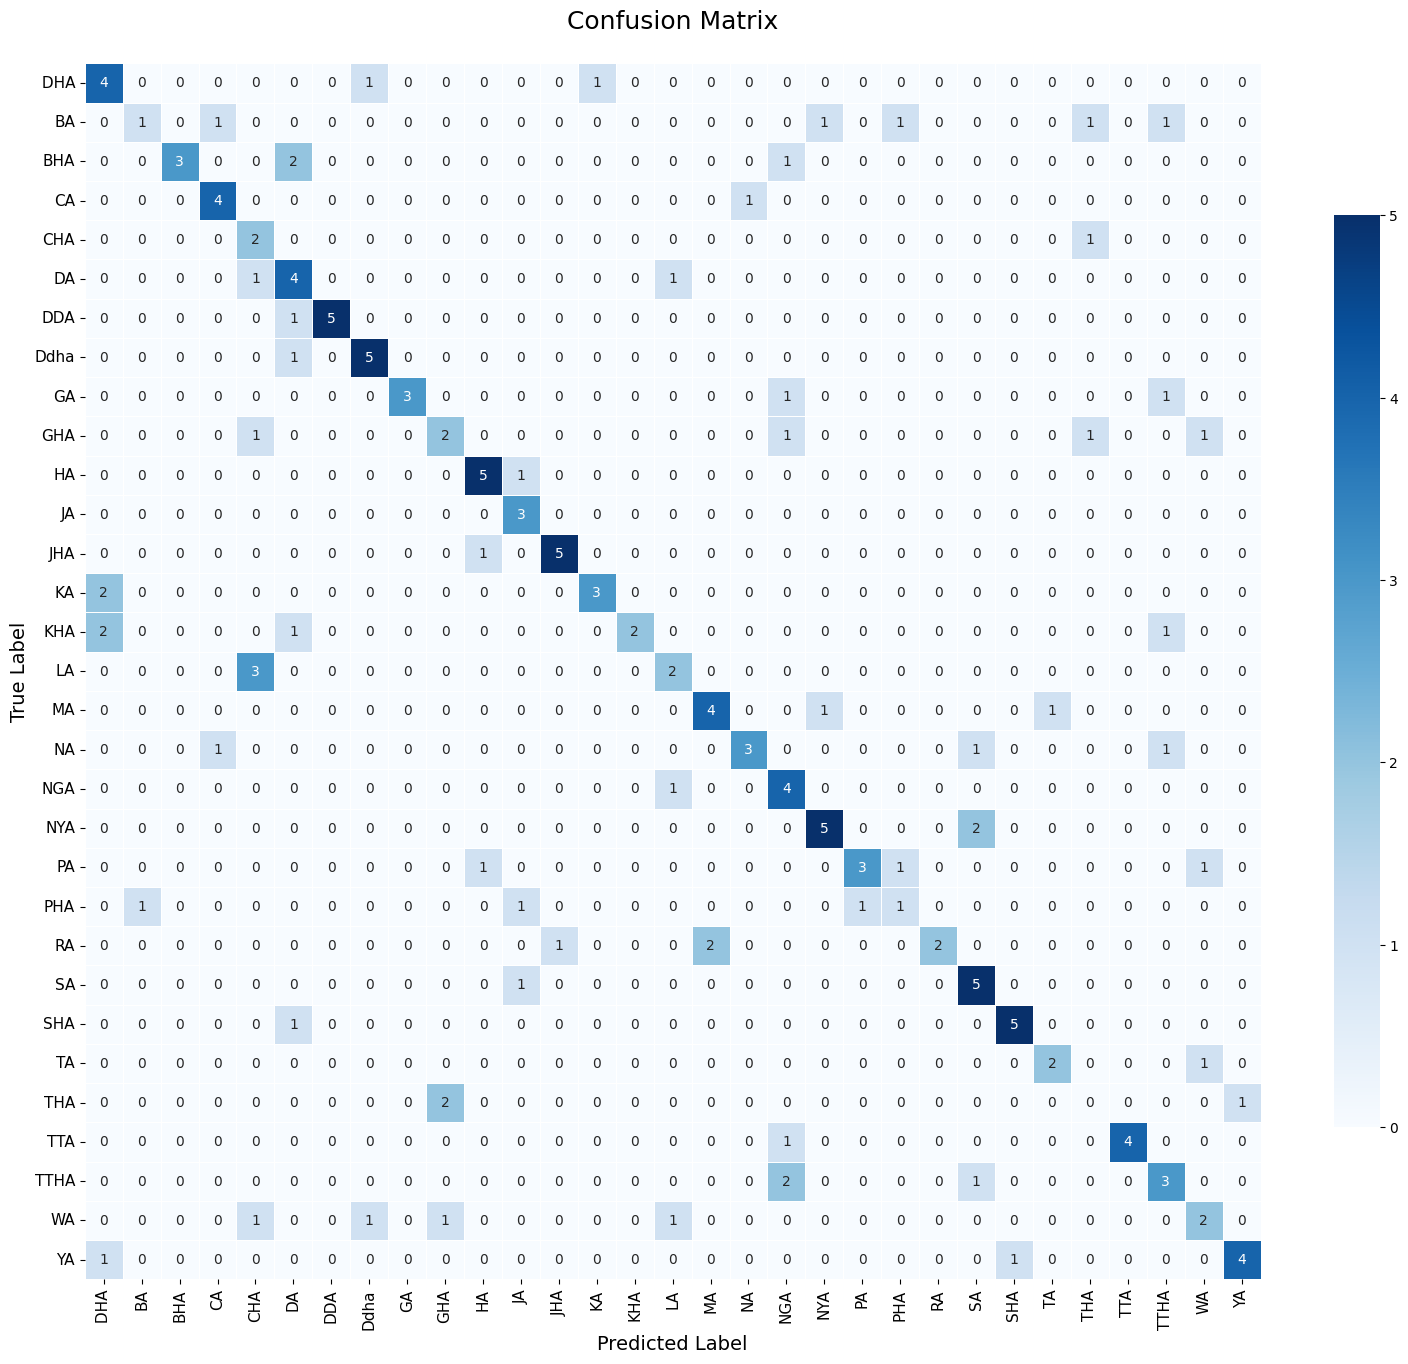


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [16]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "efficientvit_m0"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  efficientformerv2_s0
Model: efficientformerv2_s0
Trainable parameters: 1,338,878
🔁 Resuming from checkpoint...

Training finished! Best Validation Accuracy: 99.15%


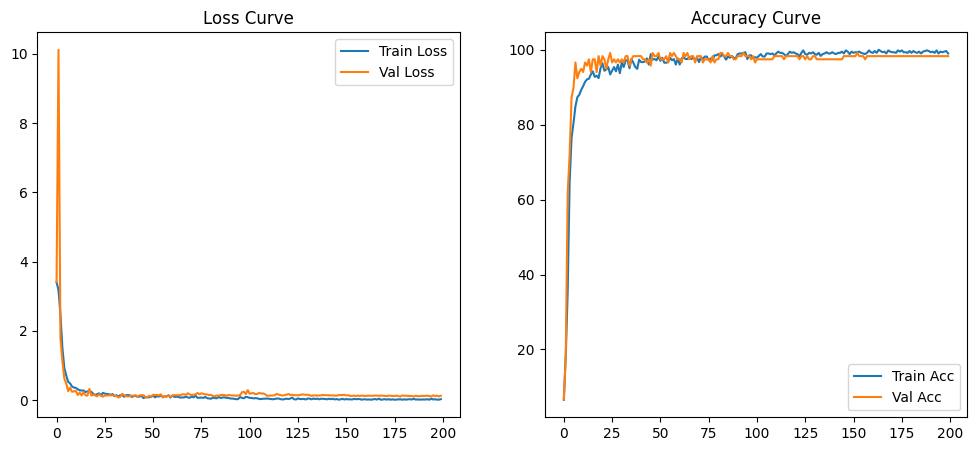

Test: 100%|██████████| 11/11 [00:00<00:00, 17.24it/s]



Final Test Accuracy: 98.19%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 19.10it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000         6
          KA     1.0000    1.0000    1.0000         5
         KHA     1.0000    1.0000    1.0000         6
          LA     1.0000    0.6000    0.7500         5
          MA     1.0000    1.0000    1.0000         6
   

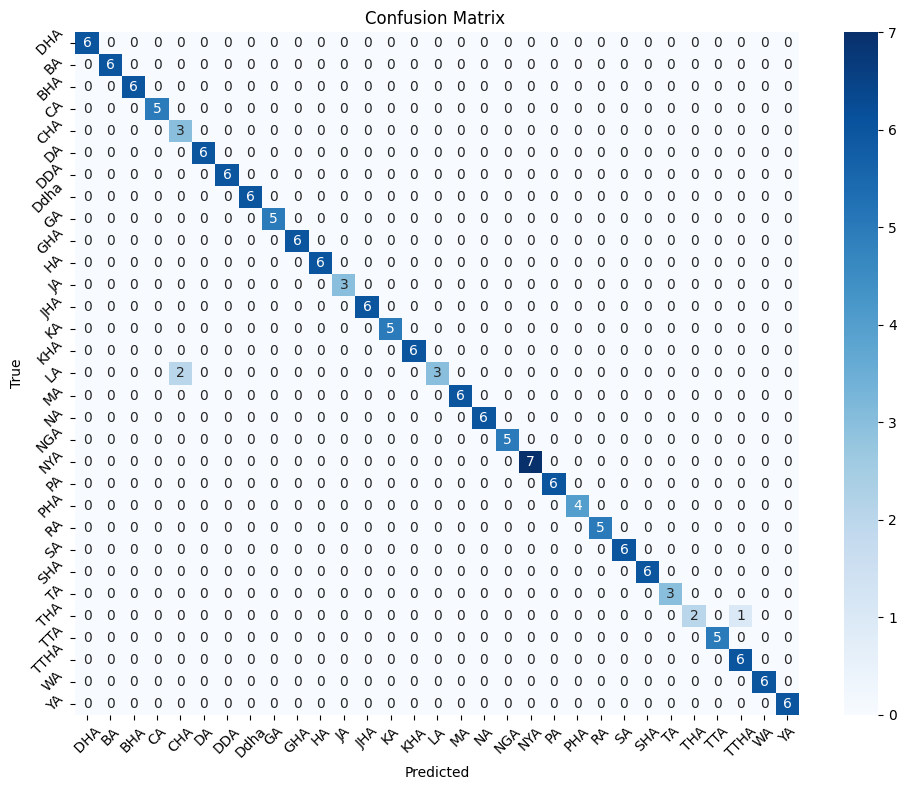

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_efficientformerv2_s0.pth

FINAL TEST METRICS
Top-1 Accuracy : 98.1928%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 98.1928%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000 

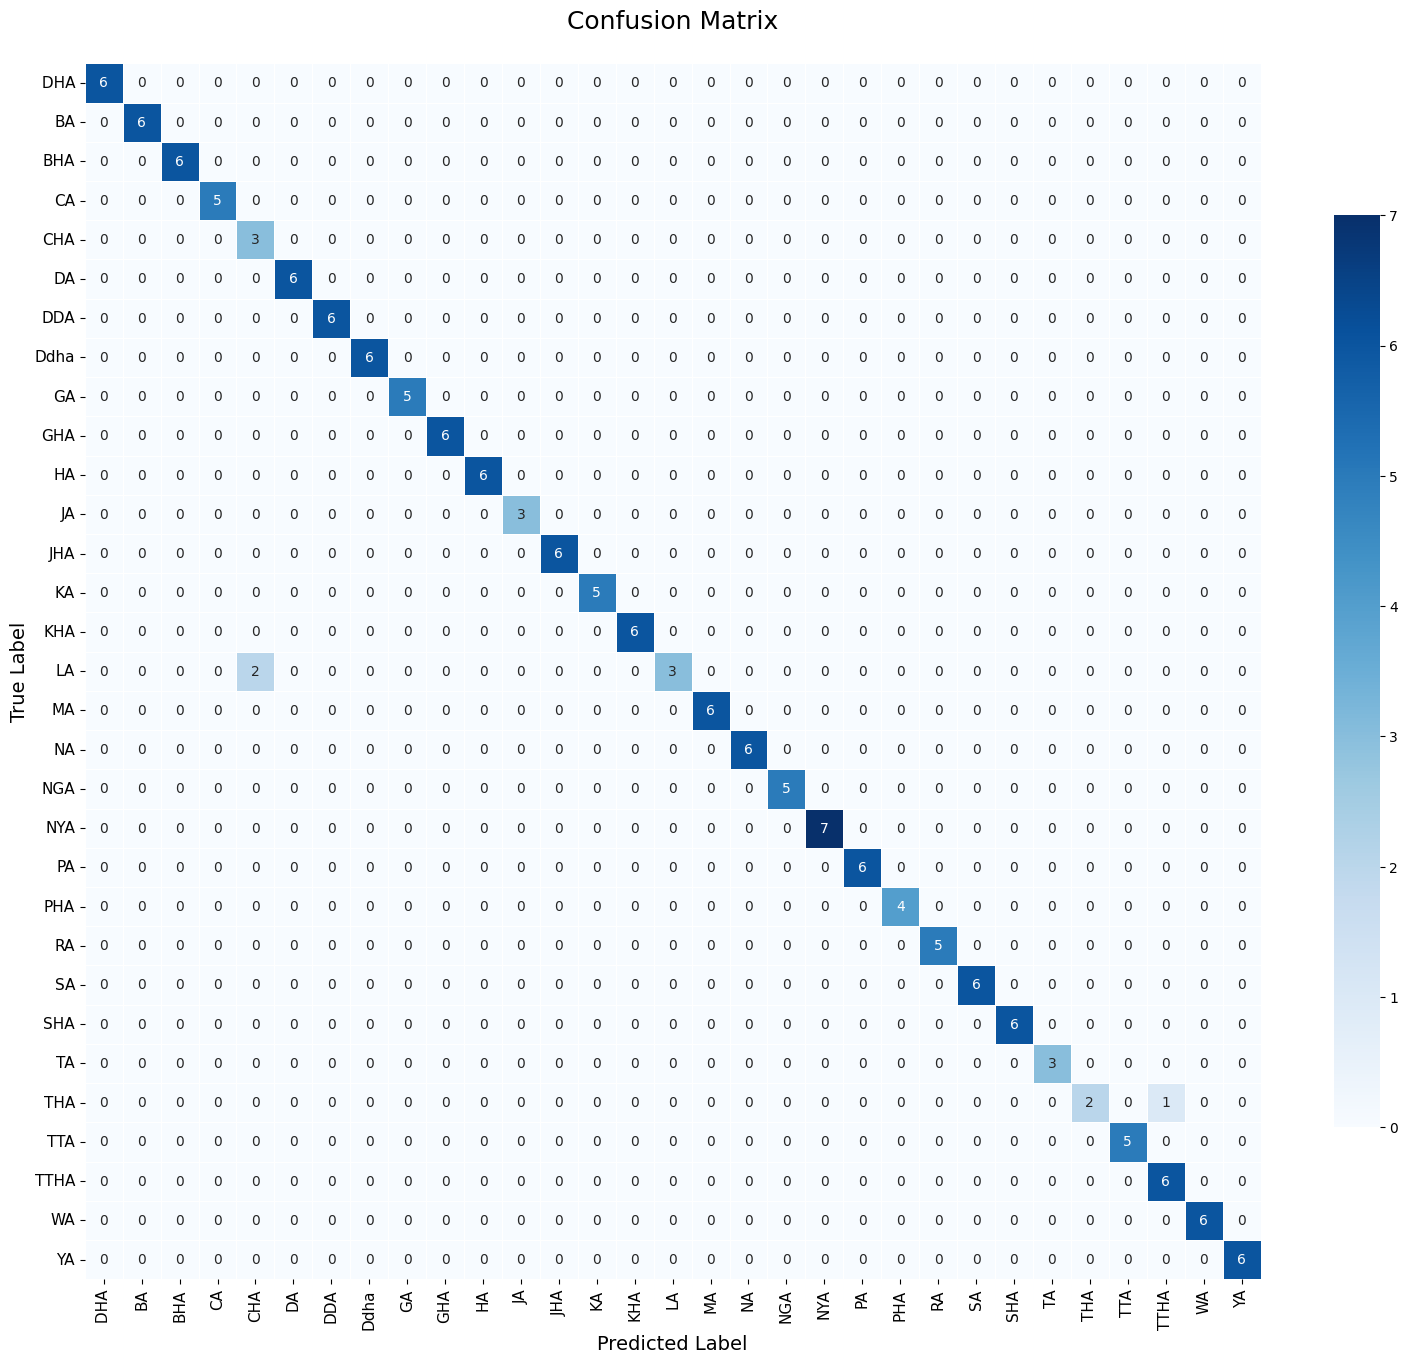


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [17]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "efficientformerv2_s0"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  fastvit_t8


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Model: fastvit_t8
Trainable parameters: 2,898,127
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 16.63it/s]


Train Loss: 3.5556 | Acc: 2.63%
Val   Loss: 3.4534 | Acc: 3.39%
✅ Best model saved! Val Acc: 3.39%

Epoch 2/200


...

Train Loss: 0.0404 | Acc: 98.52%
Val   Loss: 0.0739 | Acc: 98.31%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.24it/s]


Train Loss: 0.0348 | Acc: 98.68%
Val   Loss: 0.0748 | Acc: 98.31%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.81it/s]


Train Loss: 0.0579 | Acc: 98.36%
Val   Loss: 0.0706 | Acc: 98.31%

Training finished! Best Validation Accuracy: 99.15%


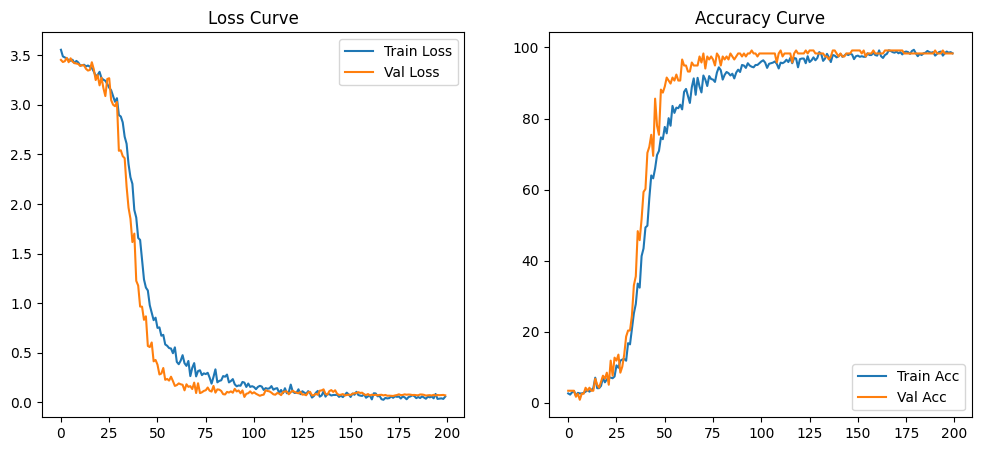

Test: 100%|██████████| 11/11 [00:00<00:00, 19.79it/s]



Final Test Accuracy: 97.59%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 20.36it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     0.8333    1.0000    0.9091         5
         CHA     0.7500    1.0000    0.8571         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     0.8571    1.0000    0.9231         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000         6
          KA     1.0000    1.0000    1.0000         5
         KHA     1.0000    1.0000    1.0000         6
          LA     1.0000    1.0000    1.0000         5
          MA     1.0000    1.0000    1.0000         6
   

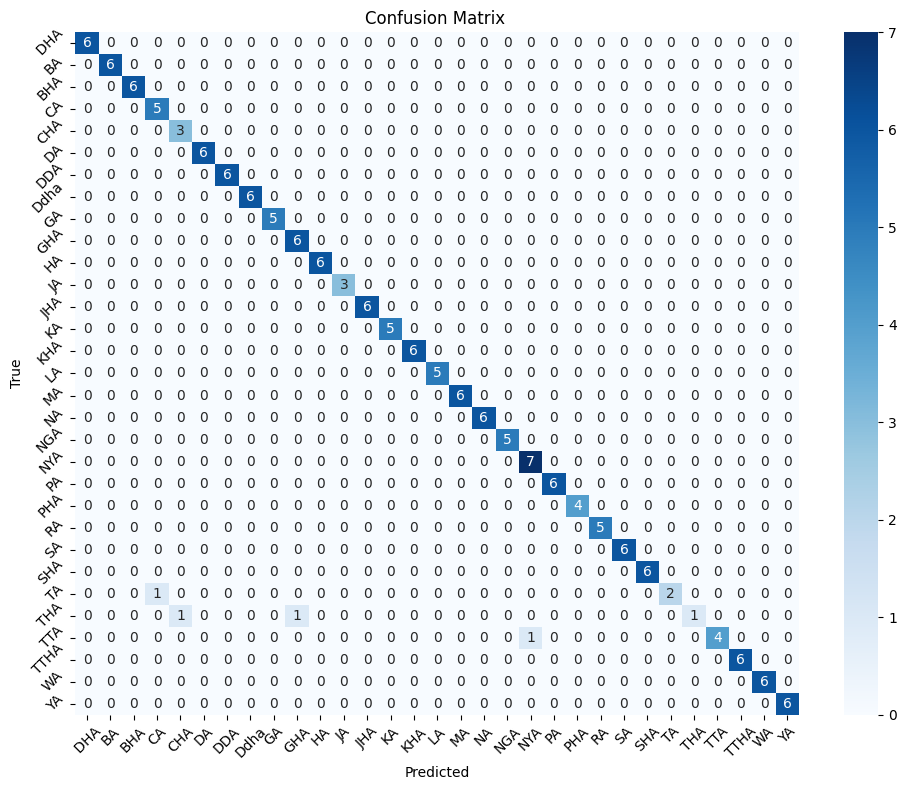

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_fastvit_t8.pth

FINAL TEST METRICS
Top-1 Accuracy : 97.5904%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 97.5904%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     0.8333    1.0000    0.9091         5
         CHA     0.7500    1.0000    0.8571         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     0.8571    1.0000    0.9231         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000 

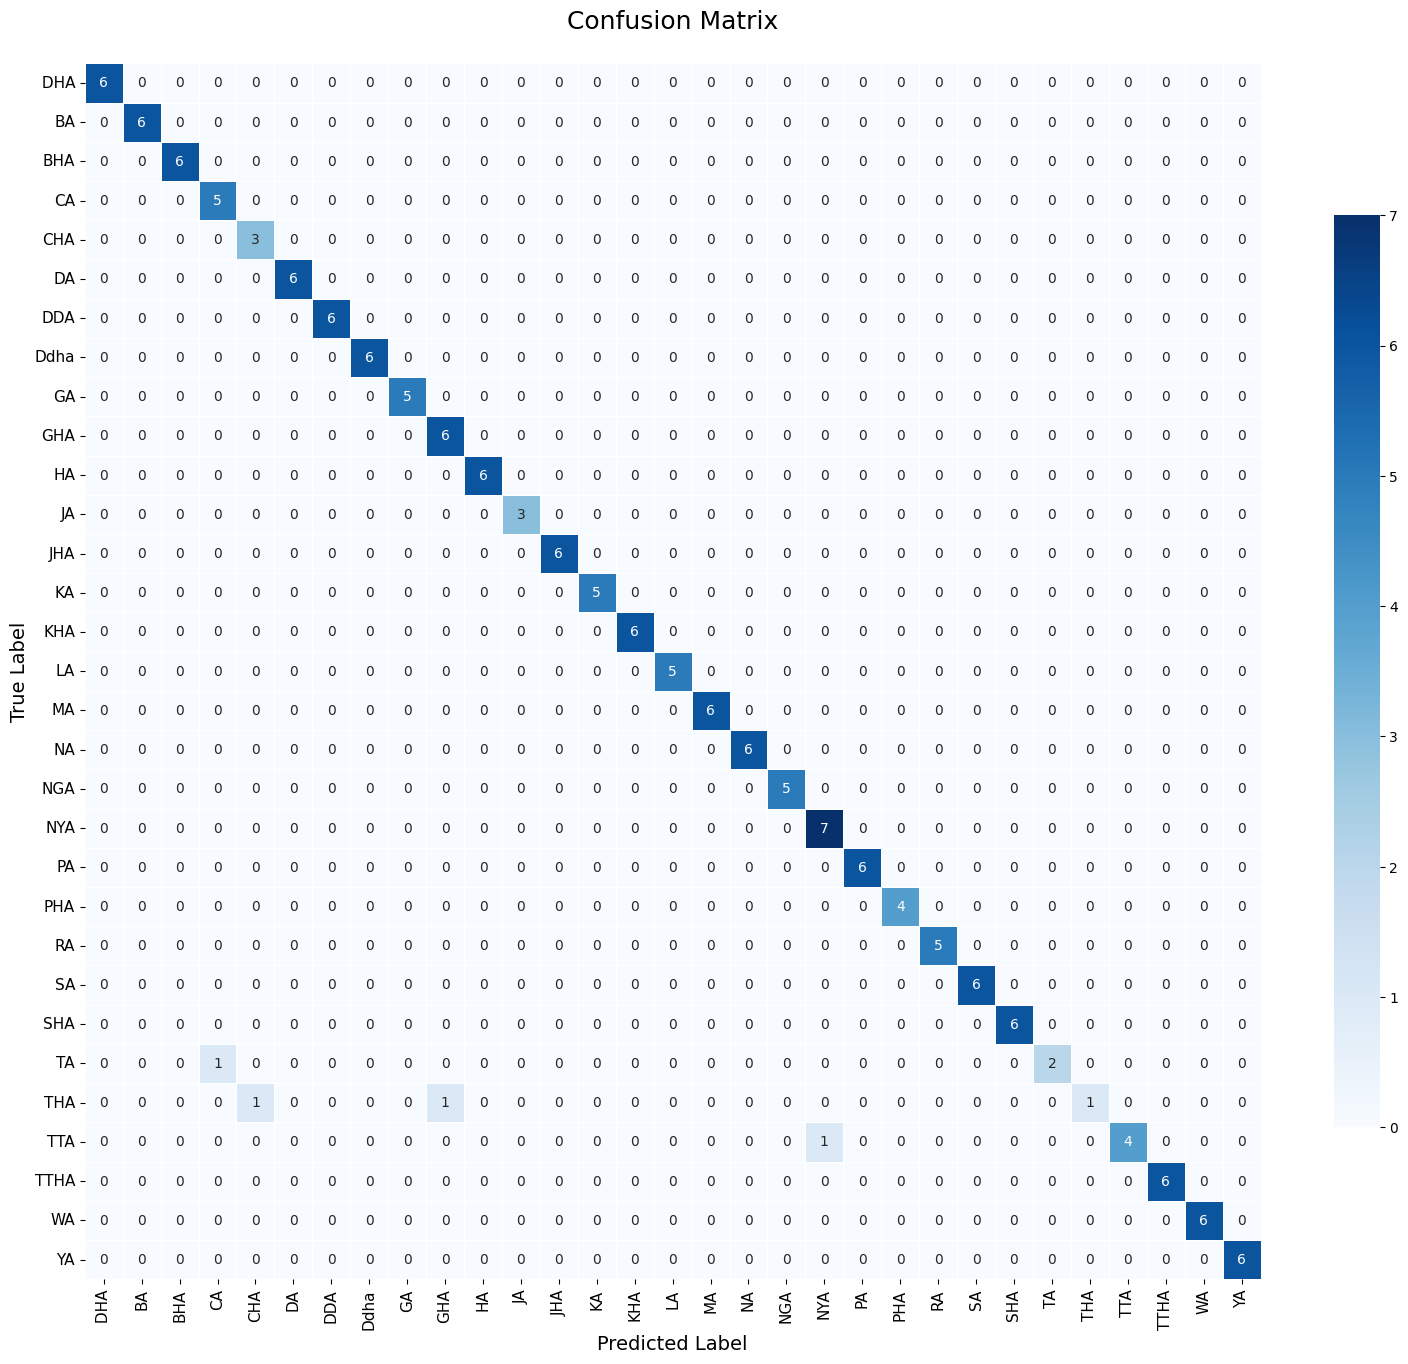


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [18]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "fastvit_t8"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  tiny_vit_5m_224


model.safetensors:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Model: tiny_vit_5m_224
Trainable parameters: 3,149,215
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 16.44it/s]


Train Loss: 3.3228 | Acc: 8.06%
Val   Loss: 2.8363 | Acc: 33.05%
✅ Best model saved! Val Acc: 33.05%

Epoch 2/200


...

Train Loss: 0.0069 | Acc: 99.51%
Val   Loss: 0.0816 | Acc: 99.15%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.80it/s]


Train Loss: 0.0057 | Acc: 99.84%
Val   Loss: 0.0805 | Acc: 99.15%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.10it/s]


Train Loss: 0.0051 | Acc: 99.84%
Val   Loss: 0.0800 | Acc: 99.15%

Training finished! Best Validation Accuracy: 99.15%


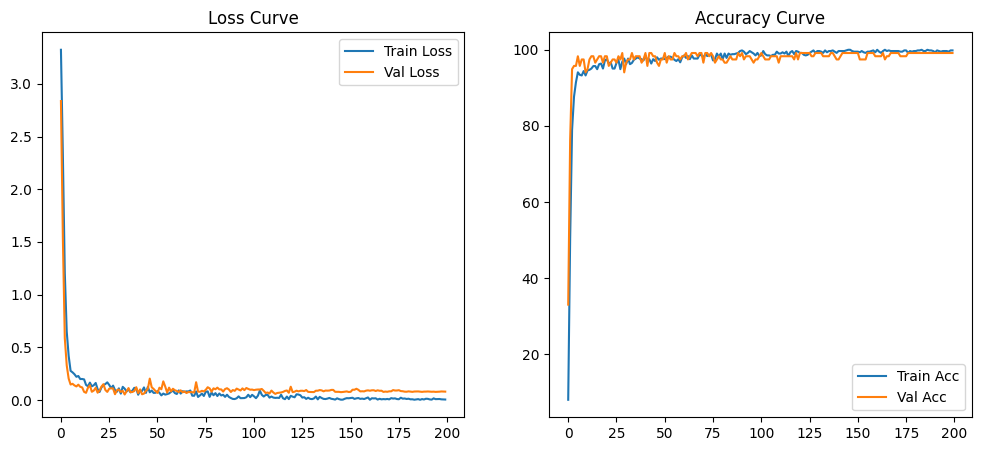

Test: 100%|██████████| 11/11 [00:00<00:00, 17.76it/s]



Final Test Accuracy: 96.99%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 19.00it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     0.8571    1.0000    0.9231         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    0.8333    0.9091         6
          KA     1.0000    0.8000    0.8889         5
         KHA     1.0000    0.6667    0.8000         6
          LA     1.0000    1.0000    1.0000         5
          MA     1.0000    1.0000    1.0000         6
   

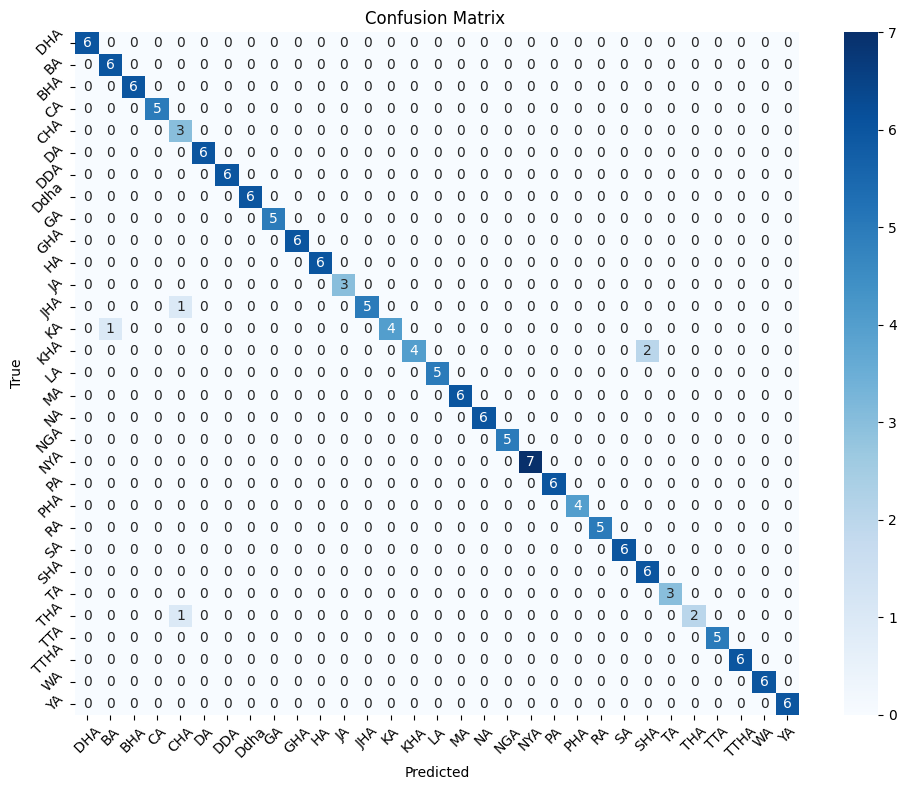

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_tiny_vit_5m_224.pth

FINAL TEST METRICS
Top-1 Accuracy : 96.9880%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 96.9880%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     0.8571    1.0000    0.9231         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     0.6000    1.0000    0.7500         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    1.0000    1.0000         6
          HA     1.0000    1.0000    1.0000         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    0.8333    0.

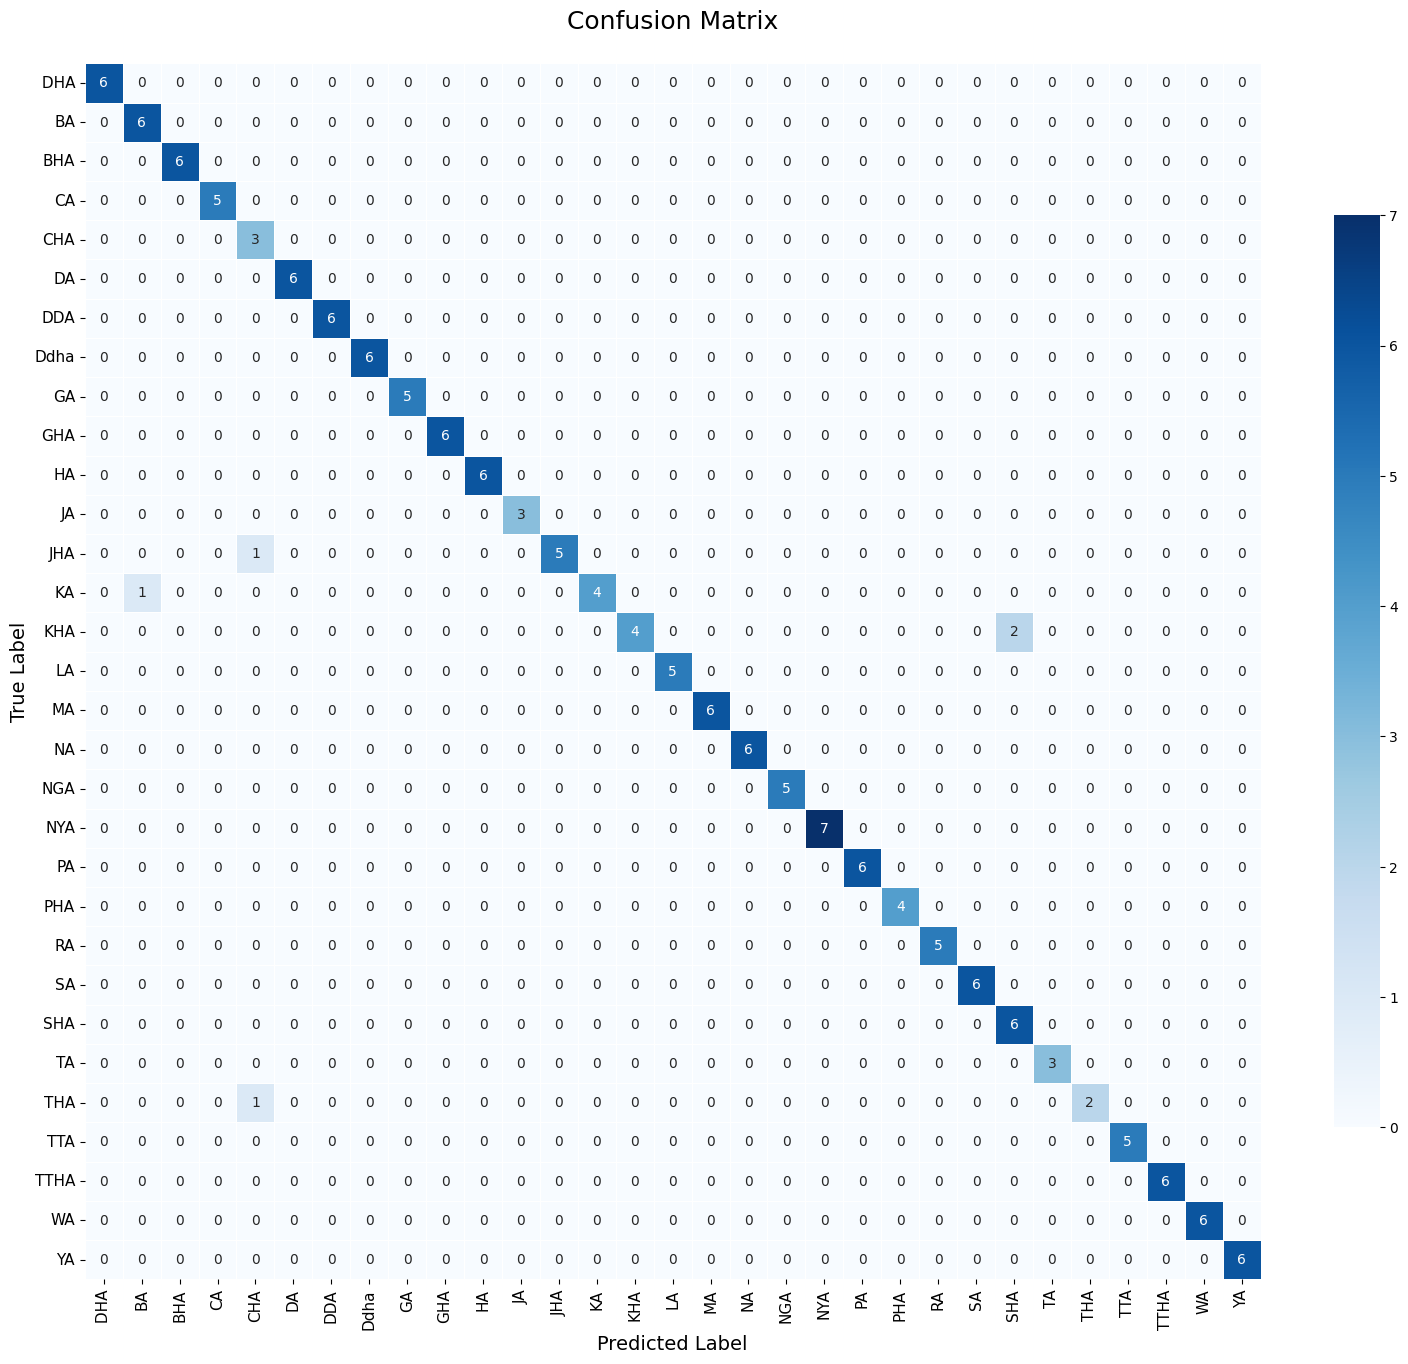


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [19]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "tiny_vit_5m_224"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")

Using device: cuda
Number of classes: 31
Classes: [' DHA', 'BA', 'BHA', 'CA', 'CHA', 'DA', 'DDA', 'Ddha', 'GA', 'GHA', 'HA', 'JA', 'JHA', 'KA', 'KHA', 'LA', 'MA', 'NA', 'NGA', 'NYA', 'PA', 'PHA', 'RA', 'SA', 'SHA', 'TA', 'THA', 'TTA', 'TTHA', 'WA', 'YA']
Class Weights: tensor([0.8668, 0.9493, 0.8306, 0.9493, 1.9935, 0.8668, 0.8668, 0.9493, 0.9968,
        0.9493, 0.8668, 2.2151, 0.8668, 1.1727, 0.9493, 1.0492, 0.9493, 0.8668,
        1.0492, 0.7120, 0.8306, 1.5335, 0.9968, 0.9062, 0.9493, 1.9935, 2.2151,
        0.9493, 0.9062, 0.8306, 0.9062], device='cuda:0')
Using Model Name -->  efficientformer_l1


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model: efficientformer_l1
Trainable parameters: 9,078,926
🚀 Starting fresh training

Epoch 1/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 18.01it/s]


Train Loss: 3.2375 | Acc: 12.34%
Val   Loss: 2.9674 | Acc: 27.12%
✅ Best model saved! Val Acc: 27.12%

Epoch 2/200


...

Train Loss: 0.0023 | Acc: 100.00%
Val   Loss: 0.1096 | Acc: 98.31%

Epoch 199/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.41it/s]


Train Loss: 0.0110 | Acc: 99.51%
Val   Loss: 0.1163 | Acc: 98.31%

Epoch 200/200


Validation: 100%|██████████| 8/8 [00:00<00:00, 17.60it/s]


Train Loss: 0.0062 | Acc: 99.84%
Val   Loss: 0.1132 | Acc: 98.31%

Training finished! Best Validation Accuracy: 99.15%


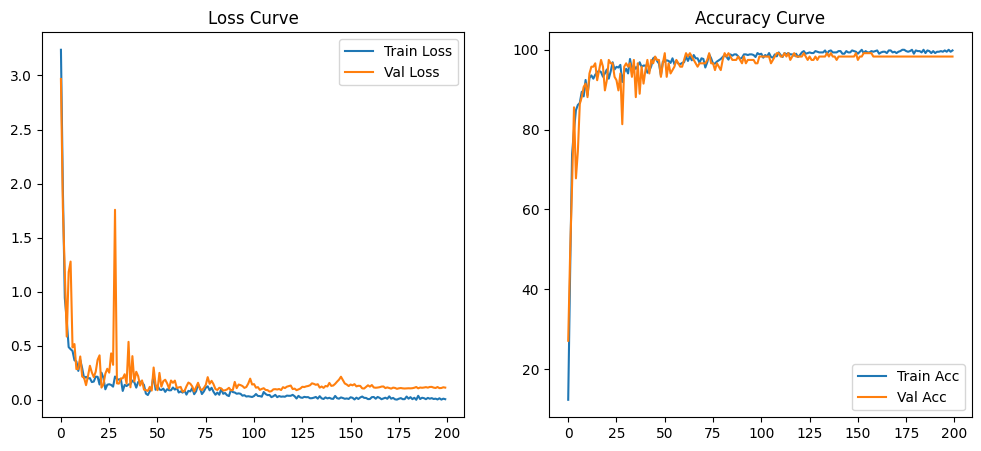

Test: 100%|██████████| 11/11 [00:00<00:00, 19.32it/s]



Final Test Accuracy: 96.99%


Predicting: 100%|██████████| 11/11 [00:00<00:00, 20.18it/s]



CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     1.0000    1.0000    1.0000         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    0.6667    0.8000         6
          HA     1.0000    0.8333    0.9091         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000    1.0000         6
          KA     1.0000    1.0000    1.0000         5
         KHA     1.0000    1.0000    1.0000         6
          LA     1.0000    1.0000    1.0000         5
          MA     0.8571    1.0000    0.9231         6
   

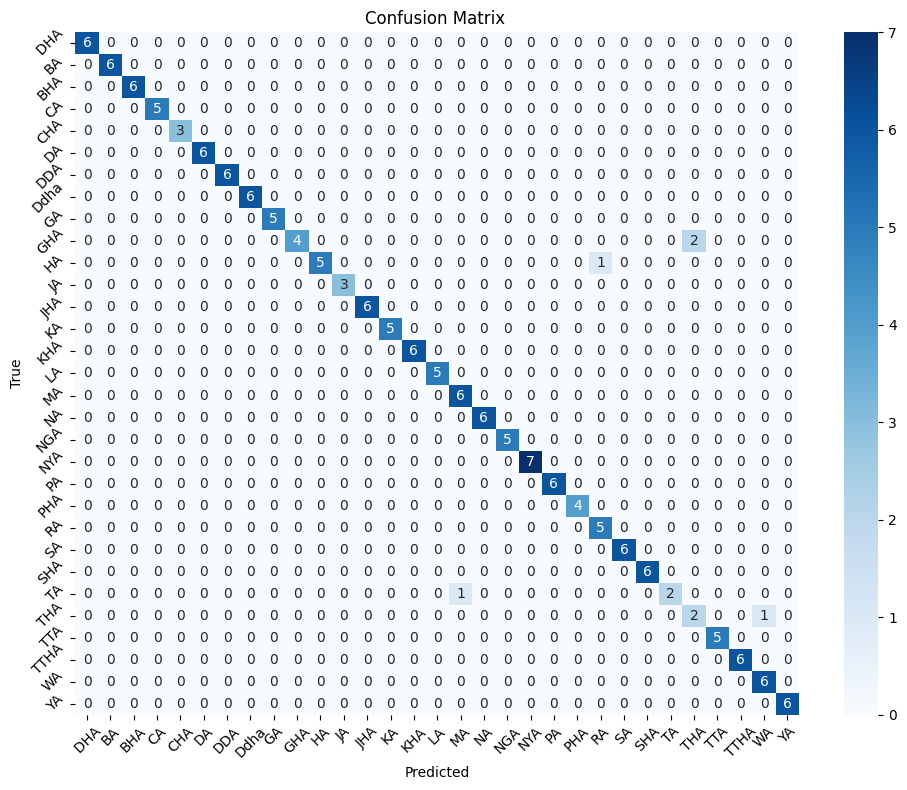

----MODEL INFERENCE AND TESTING---
Test set: 166 images, 31 classes
✅ Model loaded from models/best_mobilenetv4_42_efficientformer_l1.pth

FINAL TEST METRICS
Top-1 Accuracy : 96.9880%
Top-5 Accuracy : 100.0000%
Overall Accuracy: 96.9880%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DHA     1.0000    1.0000    1.0000         6
          BA     1.0000    1.0000    1.0000         6
         BHA     1.0000    1.0000    1.0000         6
          CA     1.0000    1.0000    1.0000         5
         CHA     1.0000    1.0000    1.0000         3
          DA     1.0000    1.0000    1.0000         6
         DDA     1.0000    1.0000    1.0000         6
        Ddha     1.0000    1.0000    1.0000         6
          GA     1.0000    1.0000    1.0000         5
         GHA     1.0000    0.6667    0.8000         6
          HA     1.0000    0.8333    0.9091         6
          JA     1.0000    1.0000    1.0000         3
         JHA     1.0000    1.0000   

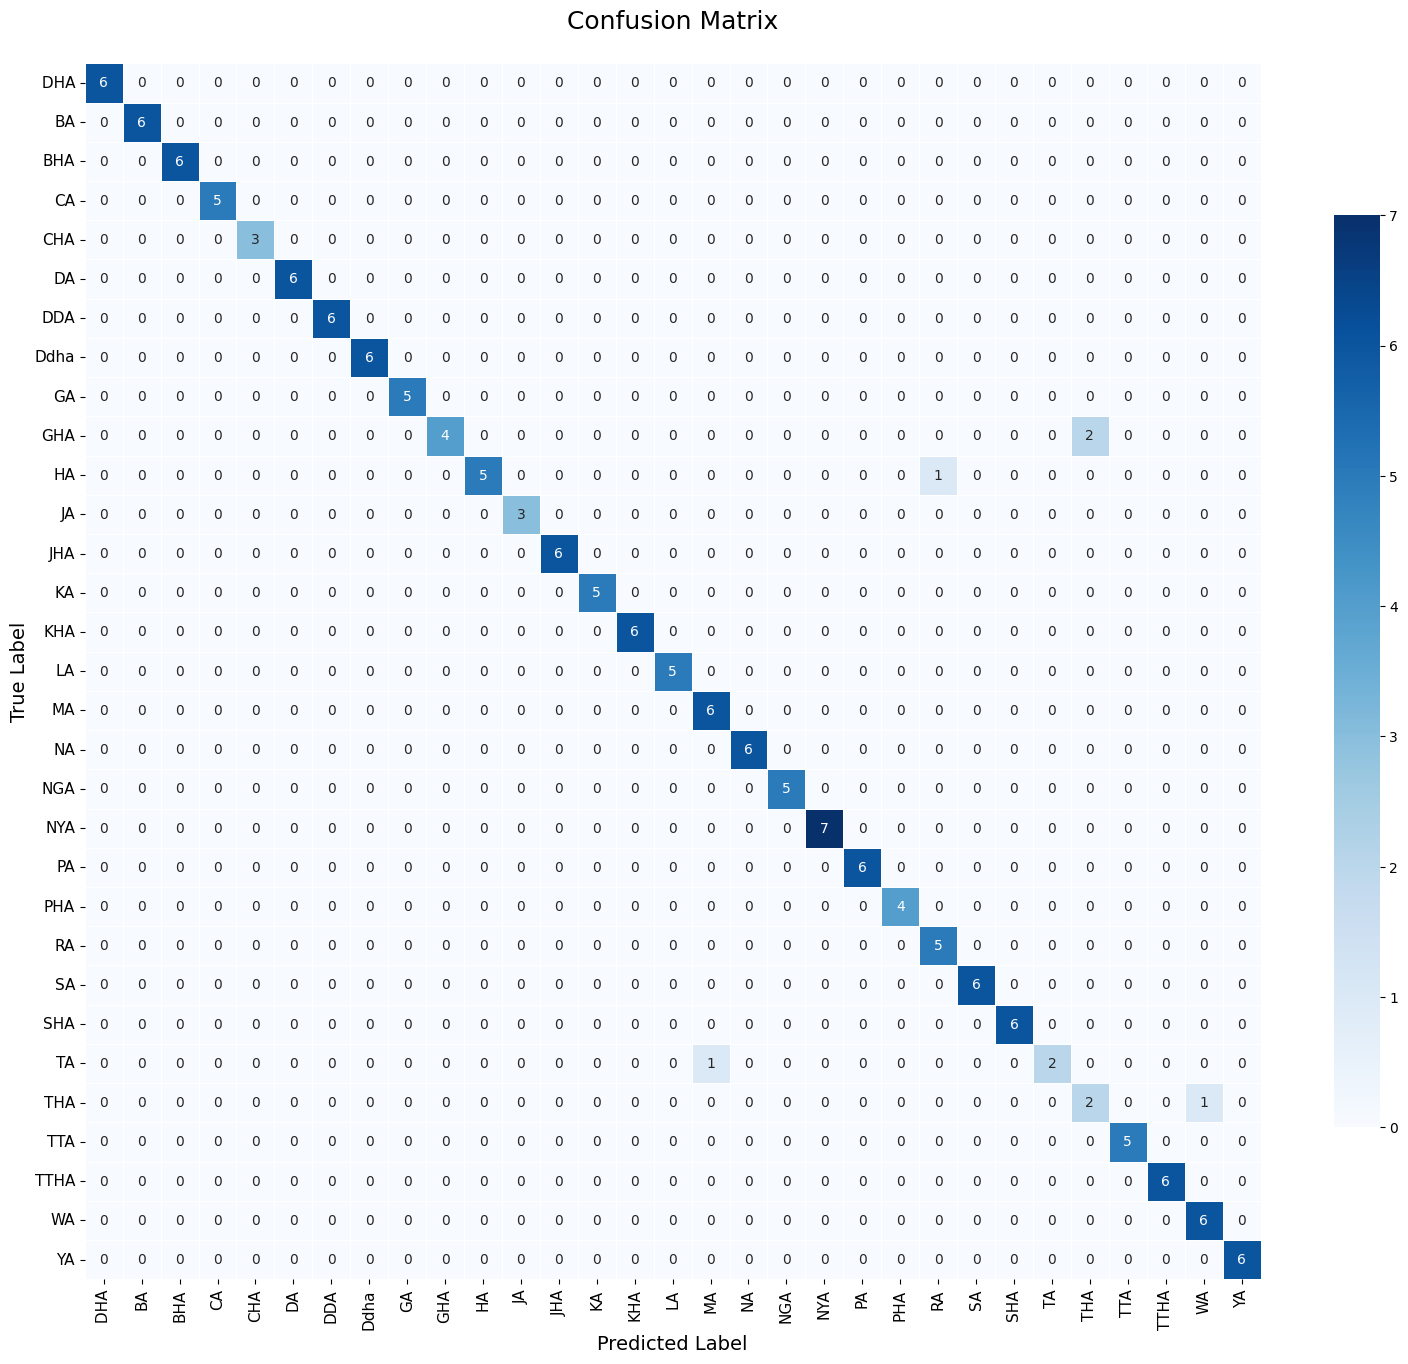


✅ High-DPI Confusion Matrix Files Saved:
   • confusion_matrix_test.png          → DPI = 400
   • confusion_matrix_test_highres.png → DPI = 600
   • confusion_matrix_test.pdf         → Vector (infinite resolution)


In [20]:
# ========================= CONFIG ========================= 
DATA_ROOT = f"/kaggle/working/kirat_rai_split_seed_{RANDOM_SEED}"

BATCH_SIZE = 16
NUM_WORKERS = 2
NUM_EPOCHS = 200

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# ========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== TRANSFORMS =======================
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(15),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    # Geometric
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.8, 1.2),
        shear=15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.3,
        p=0.5
    ),

    # Photometric
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomInvert(p=0.05),

    # Blur & noise simulation
    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.5)
    ),

    transforms.RandomGrayscale(p=0.15),

    transforms.ToTensor(),

    # OCR robustness
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS ========================
train_ds = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_ROOT}/val",   transform=val_transform)
test_ds  = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# ===================== DATALOADERS =====================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ===================== CLASS WEIGHTS =====================
train_labels = np.array([label for _, label in train_ds])
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels),
    dtype=torch.float32
).to(device)
print("Class Weights:", class_weights)

# ====================== MODEL ======================
model_name = "efficientformer_l1"


print("Using Model Name --> ", model_name)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

# Freeze backbone (recommended for small/medium datasets)
for name, param in model.named_parameters():
    if not any(x in name for x in ['head', 'classifier', 'fc']):
        param.requires_grad = False

model = model.to(device)

print(f"Model: {model_name}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS & OPTIM =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=running_loss/len(loader), acc=100.*correct/total)

    return running_loss/len(loader), 100.*correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Validation"):
    model.eval()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(loader, desc=phase):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader), 100.*correct/total

# ===================== TRAINING LOOP =====================
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = f"models/best_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"
LAST_CHECKPOINT_PATH = f"models/last_mobilenetv4_{RANDOM_SEED}_{model_name}.pth"

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Resume if checkpoint exists
if os.path.exists(LAST_CHECKPOINT_PATH):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", history)
else:
    start_epoch = 0
    print("🚀 Starting fresh training")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Update history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, BEST_MODEL_PATH)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")

    # Save last checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history
    }, LAST_CHECKPOINT_PATH)

print(f"\nTraining finished! Best Validation Accuracy: {best_val_acc:.2f}%")

# ===================== PLOTTING =====================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# ===================== FINAL TEST =====================
# Load best model for evaluation
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device, phase="Test")
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Classification Report + Confusion Matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_predictions(model, test_loader, device)

print("\n" + "="*70)
print("CLASSIFICATION REPORT ")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================= CONFIG =========================
print("----MODEL INFERENCE AND TESTING---")

# ===================== TRANSFORMS =====================
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== DATASET & LOADER =====================
test_ds = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)
class_names = test_ds.classes
num_classes = len(class_names)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images, {num_classes} classes")

# ===================== LOAD MODEL =====================
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✅ Model loaded from {BEST_MODEL_PATH}")

# ===================== TOP-K ACCURACY =====================
def topk_accuracy(output, target, k=1):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    correct_k = correct[:k].reshape(-1).float().sum(0)
    return correct_k.mul_(100.0 / batch_size).item()

@torch.no_grad()
def evaluate_topk(model, loader, device):
    model.eval()
    top1_correct = top5_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        top1_acc = topk_accuracy(outputs, labels, k=1)
        top5_acc = topk_accuracy(outputs, labels, k=5)
        
        top1_correct += top1_acc * labels.size(0) / 100.0
        top5_correct += top5_acc * labels.size(0) / 100.0
        total += labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    top1 = 100.0 * top1_correct / total
    top5 = 100.0 * top5_correct / total
    
    return top1, top5, np.array(all_labels), np.array(all_preds)

# ===================== RUN EVALUATION =====================
top1_acc, top5_acc, true_labels, pred_labels = evaluate_topk(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST METRICS")
print("="*60)
print(f"Top-1 Accuracy : {top1_acc:.4f}%")
print(f"Top-5 Accuracy : {top5_acc:.4f}%")
print(f"Overall Accuracy: {accuracy_score(true_labels, pred_labels)*100:.4f}%")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))

# Per-class accuracy
cm = confusion_matrix(true_labels, pred_labels)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("\nPer-class Accuracy:")
for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls:15s}: {acc:6.2f}%")

# ===================== HIGH-RES CONFUSION MATRIX (DPI 400+) =====================
plt.figure(figsize=(16, 14))   # Even larger for high DPI clarity

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.75}, linewidths=0.5)

plt.title('Confusion Matrix', fontsize=18, pad=25)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=2.0)

# Save with HIGH DPI
plt.savefig(f'confusion_matrix_test_{model_name}.png',dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('confusion_matrix_test_highres.png', dpi=600, bbox_inches='tight', facecolor='white')  # Extra high-res version
plt.savefig('confusion_matrix_test.pdf', bbox_inches='tight')  # Vector PDF

plt.show()

print("\n✅ High-DPI Confusion Matrix Files Saved:")
print("   • confusion_matrix_test.png          → DPI = 400")
print("   • confusion_matrix_test_highres.png → DPI = 600")
print("   • confusion_matrix_test.pdf         → Vector (infinite resolution)")